# Healthcare Analytics for Doctor Visits

## 1. Problem Statement

Access to healthcare and understanding patterns of doctor visits are critical for public health policy and resource allocation. This project aims to analyze a dataset containing demographic, health, illness, socioeconomic, and healthcare access variables to identify key factors influencing doctor visit frequencies. The goal is to uncover associations that can inform interventions and improve healthcare outcomes and efficiency.

## 2. Project Overview

This Data Analytics project will involve a comprehensive exploration of a healthcare dataset to understand the dynamics of doctor visits. We will begin by performing exploratory data analysis (EDA) to summarize the dataset's main characteristics, visualize distributions, and identify initial patterns. Subsequently, we will investigate the relationships between various independent variables (e.g., gender, age, income, health status, chronic conditions, insurance type) and the dependent variable (doctor visits). The project will conclude by synthesizing findings and discussing their implications for healthcare analytics.

## 3. Project Objectives

*   To perform thorough Exploratory Data Analysis (EDA) on the provided dataset.
*   To identify the key demographic, health, socioeconomic, and healthcare access factors associated with doctor visit frequency.
*   To analyze the impact of chronic conditions and illness on the number of doctor visits.
*   To understand how different healthcare access types (private, freepoor, freerepat) correlate with doctor visit patterns.
*   To develop insights that can inform targeted healthcare interventions and policy recommendations.

## 4. Research Questions

1.  How does `gender` and `age` independently and interactively influence the number of `visits` to the doctor?
2.  What is the relationship between `income` level and the frequency of `visits`, and how does this vary across different age groups?
3.  Is there a significant correlation between the number of `illness` occurrences and the total `visits`?
4.  How do self-reported `health` status and being `reduced` (limited activity) affect doctor `visits`?
5.  What is the impact of having `nchronic` (non-chronic) or `lchronic` (long-term chronic) conditions on the frequency of doctor `visits`?
6.  Do different healthcare coverage types (`private`, `freepoor`, `freerepat`) lead to varying `visits` patterns, and how do they compare?
7.  Are there specific demographic segments that exhibit a higher or lower propensity for doctor `visits` given their health and socioeconomic status?

## 5. Expected Analytical Outcomes

*   Identification of significant predictors of doctor visit frequency.
*   Visualizations illustrating distributions and relationships between key variables.
*   Quantifiable insights into the impact of demographic, health, and socioeconomic factors on healthcare utilization.
*   A comprehensive summary of findings and their potential implications for public health and healthcare management.
*   A clear understanding of how different health conditions and access types influence doctor-seeking behavior.

## 6. Data Import and Dataset Loading

### 6.1. Import Necessary Libraries

This section imports all the required Python libraries for data manipulation, statistical analysis, and visualization. Pandas and NumPy are crucial for efficient data handling, while Matplotlib and Seaborn are essential for creating informative plots and charts. SciPy provides additional scientific computing tools, which may be useful for statistical tests.

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For statistical analysis later on

print("Required libraries imported successfully.")

Required libraries imported successfully.


### 6.2. Load Dataset

The CSV dataset, which contains information about doctor visits and related variables, is loaded into a pandas DataFrame. This DataFrame will be the primary data structure for all subsequent analysis.

In [119]:
# Define the path to the uploaded CSV file
dataset_path = '/content/1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully into DataFrame 'df'.")

Dataset loaded successfully into DataFrame 'df'.


### 6.3. Initial Data Overview

To get a preliminary understanding of the dataset, we display the first and last five rows, along with the total number of rows and columns. This helps in quickly checking the data structure, column names, and sample values.

In [120]:
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nLast 5 rows of the dataset:")
display(df.tail())

print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


First 5 rows of the dataset:


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no



Last 5 rows of the dataset:


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no



Number of rows: 5190
Number of columns: 13


## 7. Data Cleaning and Preprocessing

### 7.1. Check Data Types and Missing Values

Before proceeding with analysis, it's essential to examine the data types of each column and identify any missing values. Incorrect data types can hinder calculations, and missing values need to be addressed appropriately to avoid biased results. This step will provide an initial assessment of data quality.

In [121]:
print("\nData types and non-null values for each column:")
df.info()

print("\nMissing values count per column:")
print(df.isnull().sum())


Data types and non-null values for each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB

Missing values count per column:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
pri

### 7.2. Handle Duplicates

Checking for and handling duplicate rows is an important step to ensure that each observation in the dataset is unique. Duplicate entries can lead to skewed analyses and incorrect statistical inferences.

In [122]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]

if duplicates_removed > 0:
    print(f"Successfully removed {duplicates_removed} duplicate rows.")
    print(f"New number of rows: {df.shape[0]}")
else:
    print("No duplicate rows found.")

No duplicate rows found.


### 7.3. Descriptive Statistics

Descriptive statistics provide a summary of the central tendency, dispersion, and shape of a dataset's distribution. This step is crucial for understanding the basic characteristics of numerical variables and identifying potential outliers or anomalies. For categorical variables, we will look at value counts.

In [123]:
print("\nDescriptive statistics for numerical columns:")
display(df.describe())

print("\nValue counts for categorical columns (gender, private, freepoor, freerepat, nchronic, lchronic):")
for col in ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts())
    else:
        print(f"Column '{col}' not found in DataFrame.")


Descriptive statistics for numerical columns:


,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000



Value counts for categorical columns (gender, private, freepoor, freerepat, nchronic, lchronic):

--- gender ---
gender
female    2702
male      2488
Name: count, dtype: int64

--- private ---
private
no     2892
yes    2298
Name: count, dtype: int64

--- freepoor ---
freepoor
no     4968
yes     222
Name: count, dtype: int64

--- freerepat ---
freerepat
no     4099
yes    1091
Name: count, dtype: int64

--- nchronic ---
nchronic
no     3098
yes    2092
Name: count, dtype: int64

--- lchronic ---
lchronic
no     4585
yes     605
Name: count, dtype: int64


## 8. Exploratory Data Analysis (EDA)

### 8.1. Distribution of Doctor Visits (`visits`)

Understanding the distribution of the target variable (`visits`) is fundamental. This analysis will show how many times individuals visit the doctor and help identify the most common patterns, including the proportion of individuals who do not visit the doctor at all.

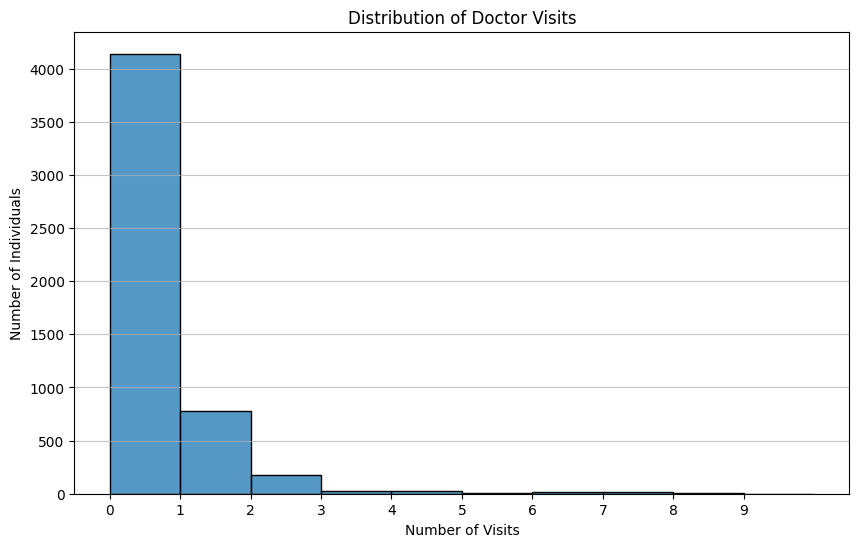


Value counts for 'visits' variable:
visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64


In [124]:
plt.figure(figsize=(10, 6))
sns.histplot(df['visits'], bins=range(df['visits'].max() + 2), kde=False, stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Number of Individuals')
plt.xticks(range(df['visits'].max() + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nValue counts for 'visits' variable:")
print(df['visits'].value_counts().sort_index())

### 8.2. Demographic Analysis: Gender and Age Distribution

Analyzing `gender` and `age` distribution helps in understanding the demographic makeup of the dataset. This is crucial for evaluating how these factors might influence doctor visits later on. We will visualize these distributions to get a clear picture.

/tmp/ipykernel_1507/3796932852.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', ax=axes[0], palette='viridis')


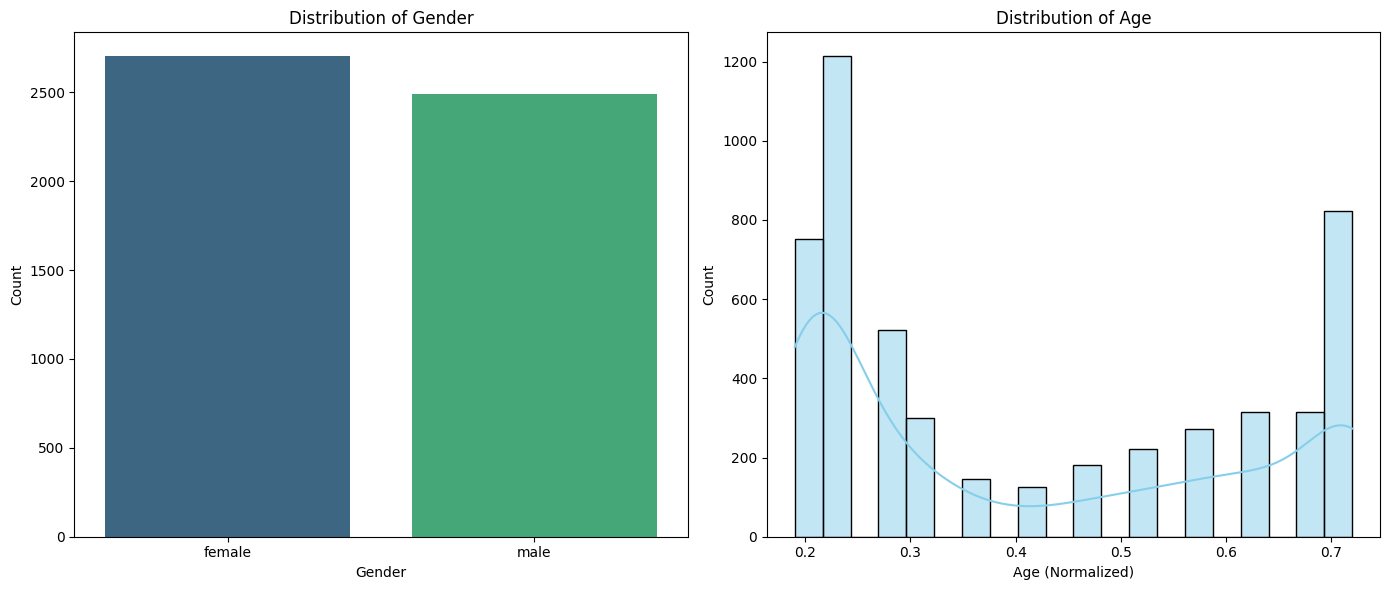

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x='gender', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

sns.histplot(df['age'], bins=20, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Age')
axes[1].set_xlabel('Age (Normalized)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 8.3. Socioeconomic Analysis: Income Distribution

Income is a key socioeconomic factor that can influence access to healthcare and frequency of doctor visits. Visualizing its distribution will provide insights into the economic profile of the individuals in the dataset.

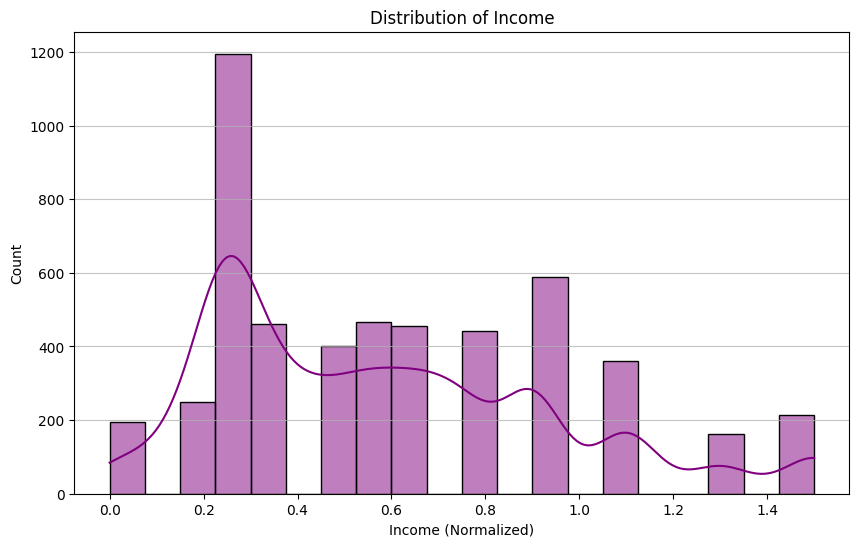

In [126]:
plt.figure(figsize=(10, 6))
sns.histplot(df['income'], bins=20, kde=True, color='purple')
plt.title('Distribution of Income')
plt.xlabel('Income (Normalized)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### 8.4. Health Status Analysis: Illness, Reduced Activity, and General Health

These variables are crucial for understanding the health profile of the dataset and how they might correlate with doctor visits. `illness` indicates the number of illnesses, `reduced` indicates days of reduced activity, and `health` could be a self-reported health score or number of conditions. Visualizing their distributions will reveal common health patterns.

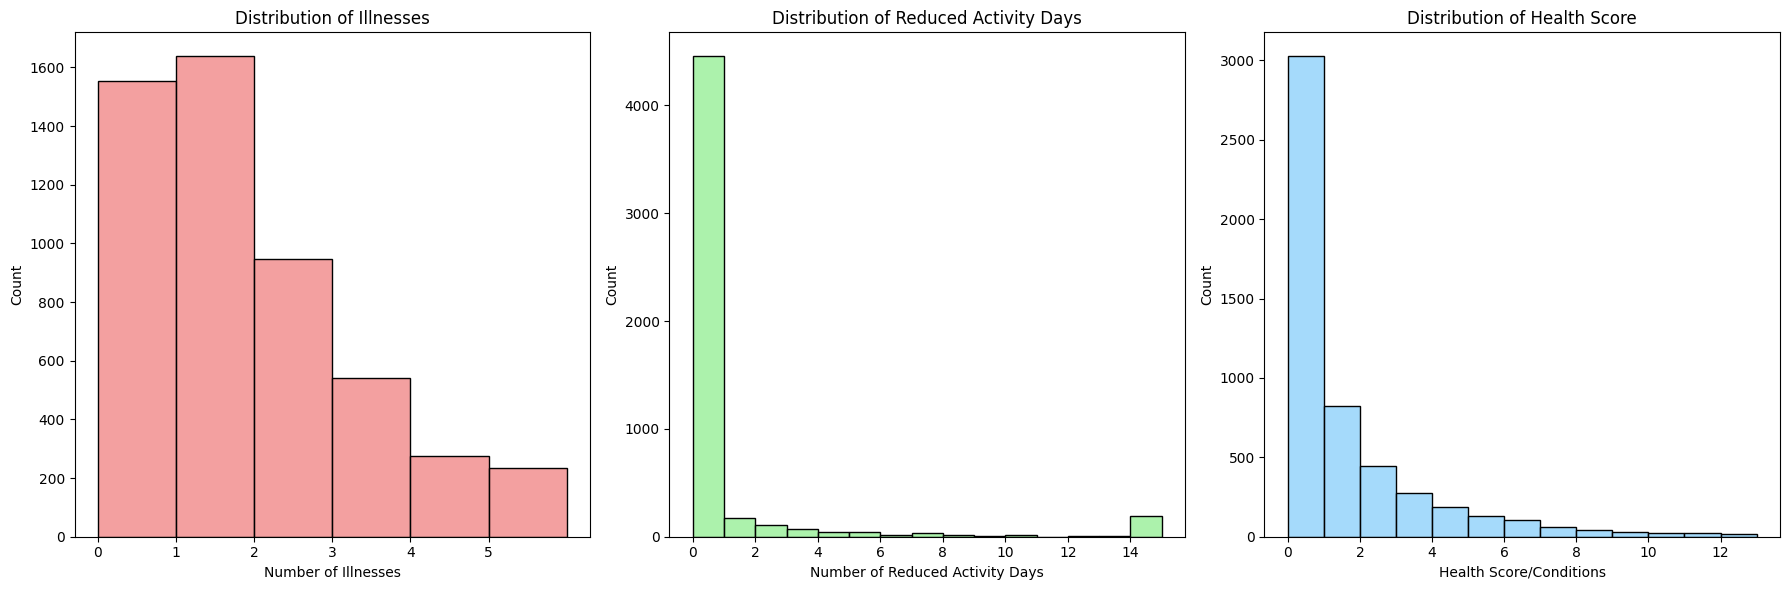

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(df['illness'], bins=range(df['illness'].max() + 2), kde=False, stat='count', ax=axes[0], color='lightcoral')
axes[0].set_title('Distribution of Illnesses')
axes[0].set_xlabel('Number of Illnesses')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(df['illness'].max() + 1))

sns.histplot(df['reduced'], bins=range(df['reduced'].max() + 2), kde=False, stat='count', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Reduced Activity Days')
axes[1].set_xlabel('Number of Reduced Activity Days')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(0, df['reduced'].max() + 1, 2))

sns.histplot(df['health'], bins=range(df['health'].max() + 2), kde=False, stat='count', ax=axes[2], color='lightskyblue')
axes[2].set_title('Distribution of Health Score')
axes[2].set_xlabel('Health Score/Conditions')
axes[2].set_ylabel('Count')
axes[2].set_xticks(range(0, df['health'].max() + 1, 2))

plt.tight_layout()
plt.show()

### 8.6. Relationship between Categorical Variables and Doctor Visits

To understand how categorical factors influence doctor visits, we will use bar plots or box plots. This will allow us to visually compare the average number of visits (or the distribution of visits) across different categories for variables like `gender`, `private` insurance, `freepoor` status, `freerepat` status, `nchronic` conditions, and `lchronic` conditions. This directly addresses parts of Research Questions 1, 5, and 6.

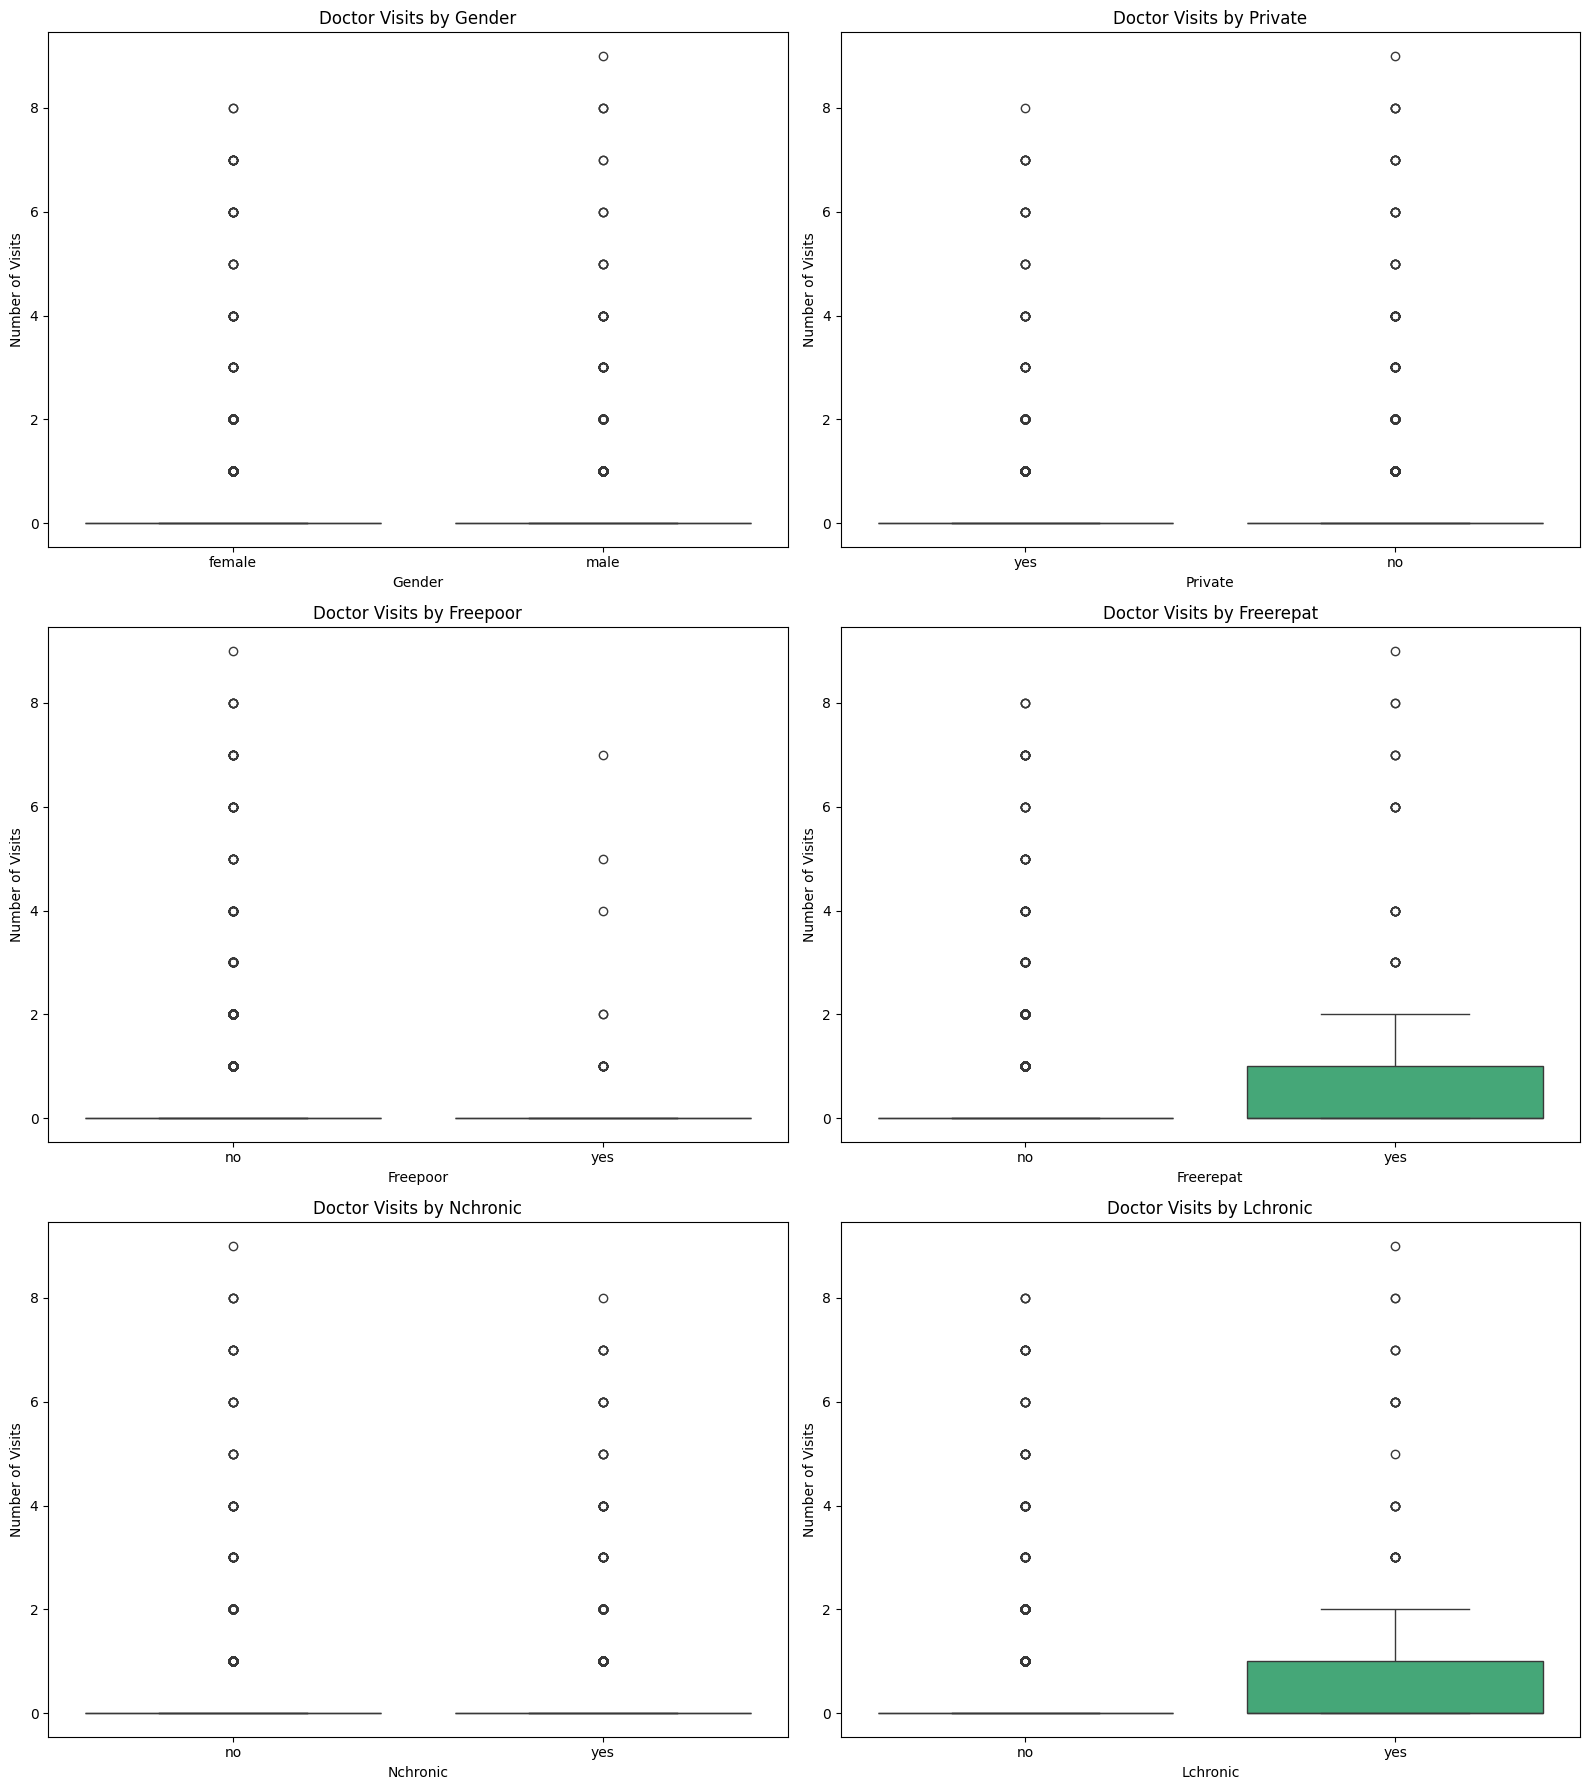

In [128]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

categorical_features = ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

for i, col in enumerate(categorical_features):
    sns.boxplot(data=df, x=col, y='visits', ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Doctor Visits by {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Number of Visits')

plt.tight_layout()
plt.show()

### 8.7. Relationship between Numerical Variables and Doctor Visits

For numerical variables like `age`, `income`, `illness`, `reduced`, and `health`, we will examine their relationship with `visits` using scatter plots and possibly correlation coefficients. This helps to identify trends and the strength of associations, addressing Research Questions 1, 2, 3, and 4.

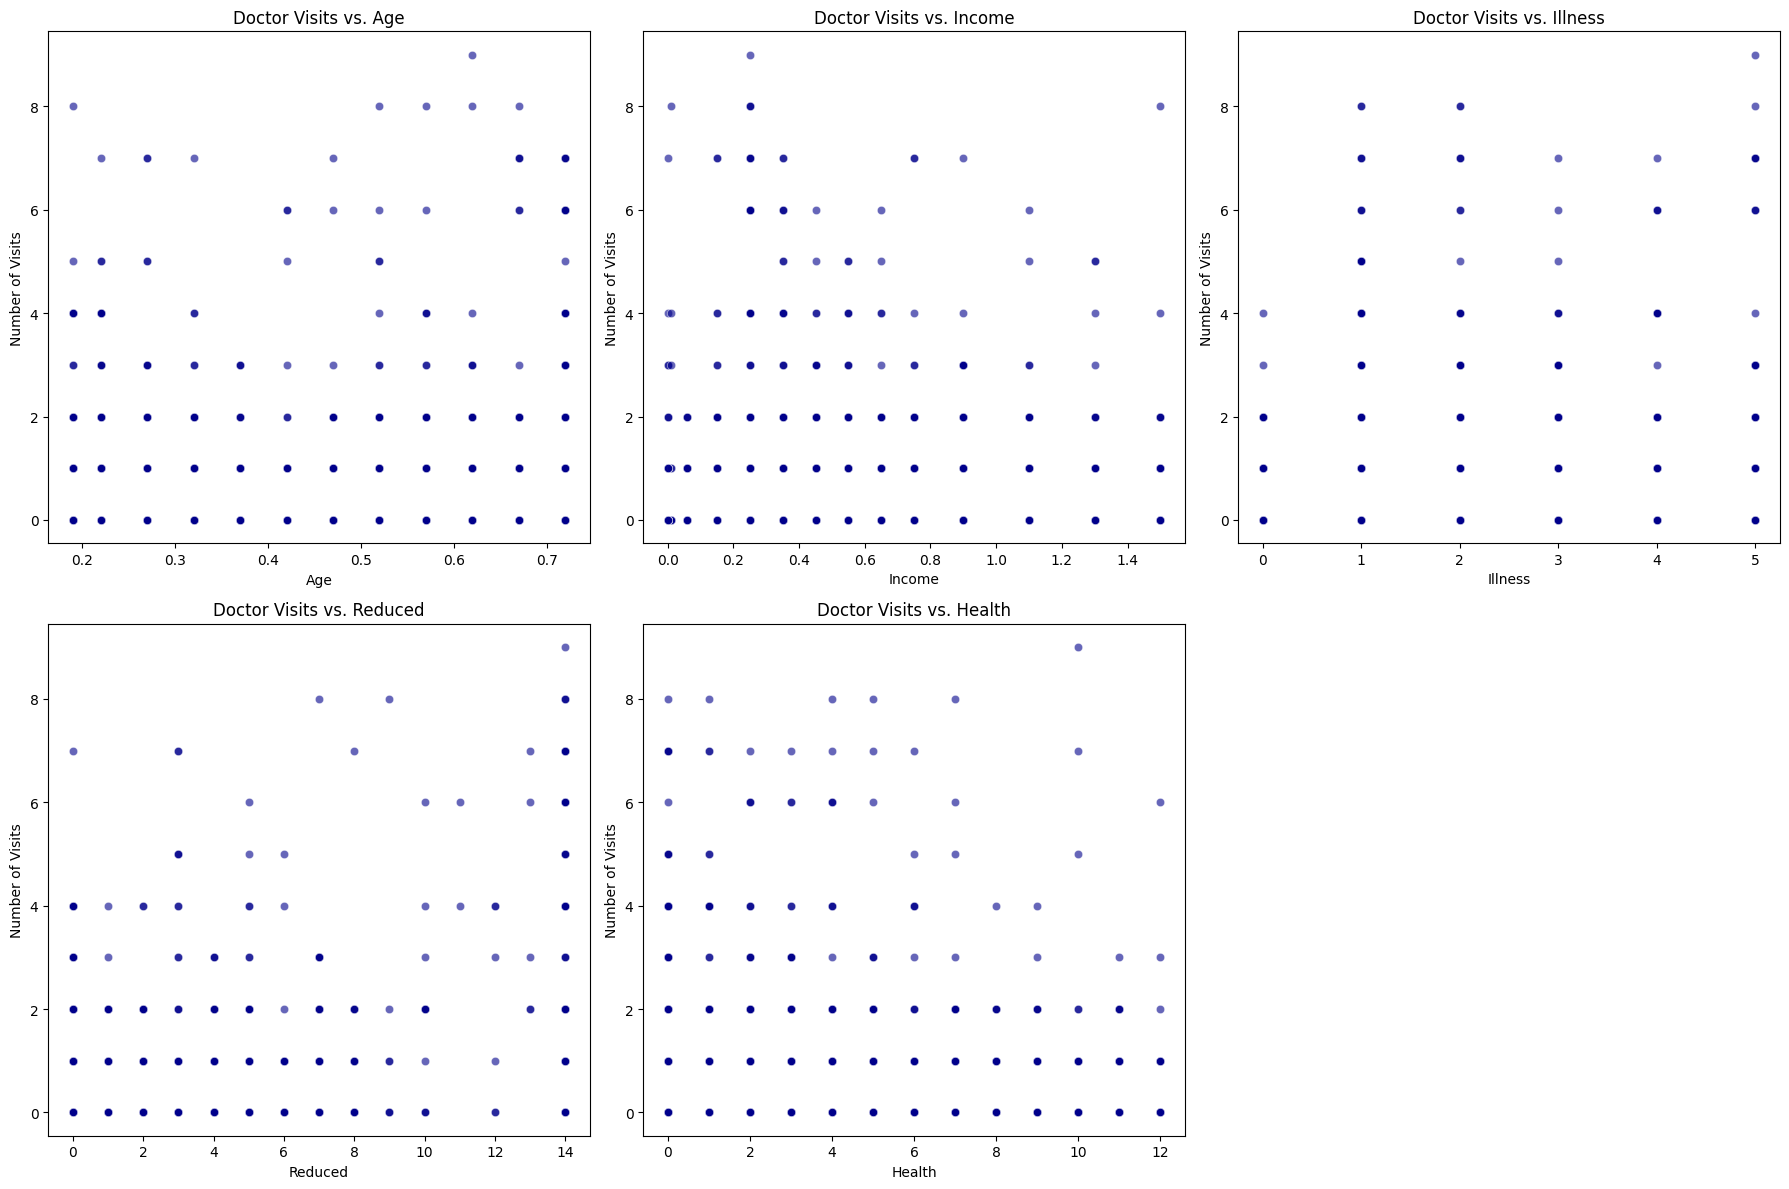


Correlation matrix between numerical features and visits:
visits     1.000000
reduced    0.418954
illness    0.223552
health     0.193272
age        0.124537
income    -0.076840
Name: visits, dtype: float64


In [129]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

numerical_features = ['age', 'income', 'illness', 'reduced', 'health']

for i, col in enumerate(numerical_features):
    sns.scatterplot(data=df, x=col, y='visits', ax=axes[i], alpha=0.6, color='darkblue')
    axes[i].set_title(f'Doctor Visits vs. {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Number of Visits')

# Hide any unused subplots
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\nCorrelation matrix between numerical features and visits:")
print(df[numerical_features + ['visits']].corr()['visits'].sort_values(ascending=False))

## Outlier and Extreme-Value Analysis

Outlier analysis is used to identify observations that are unusually distant
from the central distribution of a numerical variable.

However, the healthcare dataset contains several discrete and highly
zero-concentrated variables. Therefore, a standard IQR rule may flag many
legitimate observations as statistical extremes.

The analysis below identifies potential extreme values for investigation, but
does not automatically classify them as errors or remove them.

In [130]:
# Identify potential extreme values using the IQR method

outlier_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health']

outlier_results = []

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    potential_extremes = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    outlier_results.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Potential Extreme Values': len(potential_extremes),
        'Percentage': round(
            len(potential_extremes) / len(df_clean) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Extreme Values,Percentage
0,visits,0.00,0.00,0.00,0.000,0.000,1049,20.21
1,age,0.22,0.62,0.40,-0.380,1.220,0,0.00
2,income,0.25,0.90,0.65,-0.725,1.875,0,0.00
3,illness,0.00,2.00,2.00,-3.000,5.000,0,0.00
4,reduced,0.00,0.00,0.00,0.000,0.000,736,14.18
5,health,0.00,2.00,2.00,-3.000,5.000,303,5.84


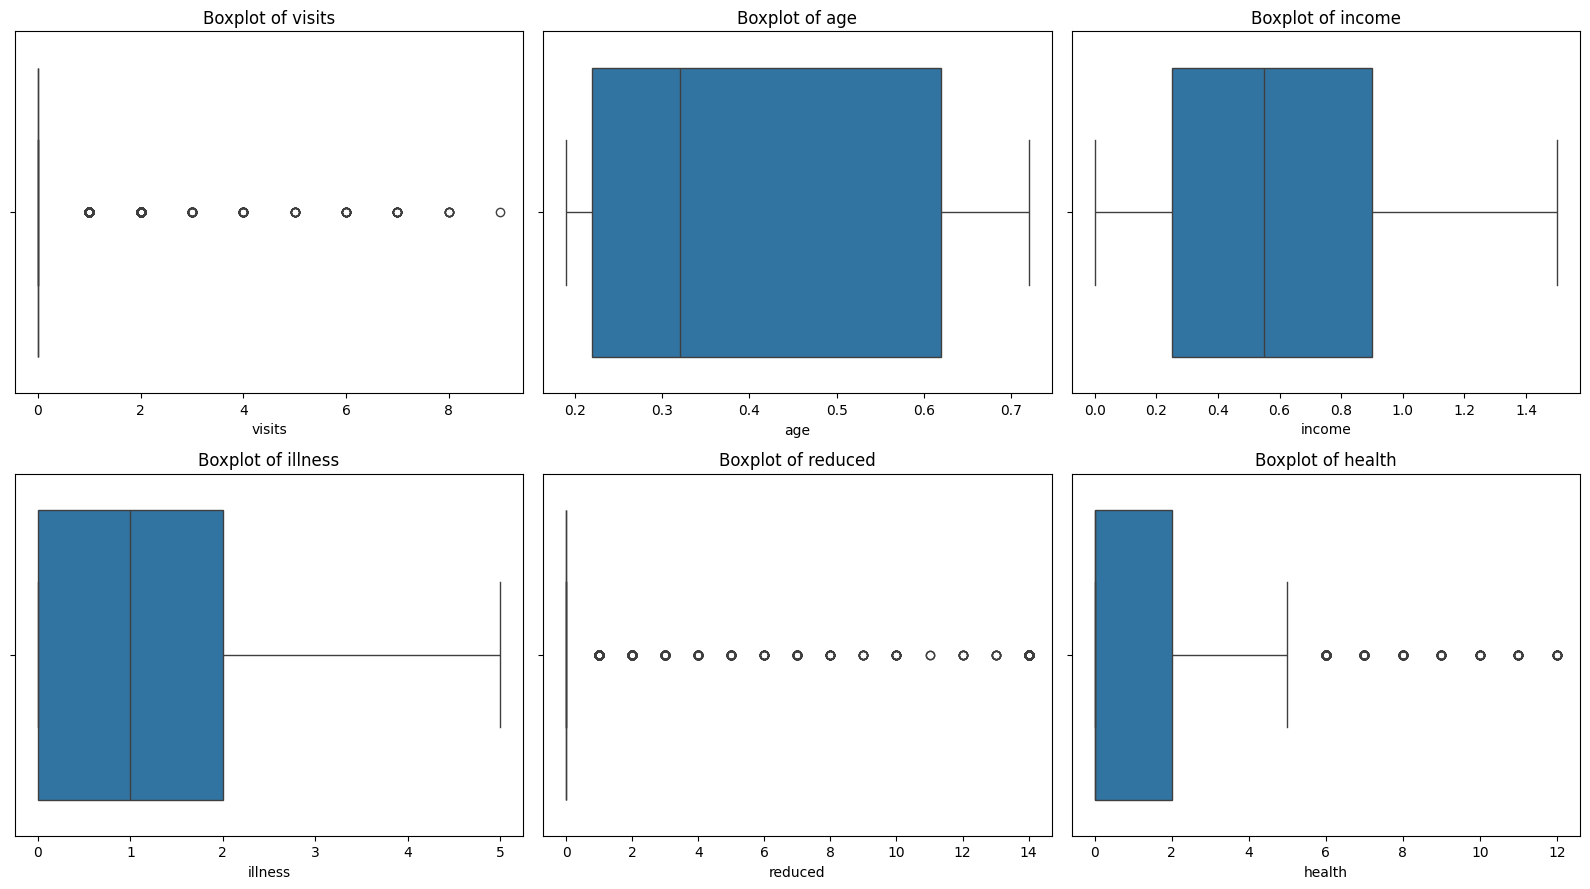

In [131]:
# Visualize the distributions of the main numerical variables

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(data=df_clean, x=col, ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### Interpretation

The IQR method identifies several statistical extremes, particularly for
variables such as doctor visits, reduced activity, and health.

However, these variables are discrete and heavily concentrated around zero.
Consequently, a large number of observations can be mathematically classified
as potential outliers even though they may represent legitimate observations.

Therefore, these observations were retained rather than removed automatically.
In a healthcare dataset, unusually high healthcare utilization may represent
genuine differences between individuals rather than data-entry errors.

## 14. Data Quality Assessment

This section performs a comprehensive assessment of the dataset's quality. We will systematically check for common data issues such as missing values, duplicate entries, inconsistent data types, and unexpected values in both categorical and numerical columns. The goal is to identify potential problems that could impact the reliability of our analysis and model building.

### 14.1. Missing Values Analysis

In [132]:
# Calculate missing values and their percentages
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

# Filter to show only columns with missing values
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if missing_data.empty:
    print("No missing values found in the dataset.")
else:
    print("Summary of Missing Values:")
    display(missing_data)

No missing values found in the dataset.


### 14.2. Duplicate Rows Analysis

In [133]:
duplicate_rows = df.duplicated().sum()

if duplicate_rows == 0:
    print("No duplicate rows found in the dataset.")
else:
    print(f"Found {duplicate_rows} duplicate rows.")
    print("These rows represent exact copies of other rows across all columns. While no action is taken at this stage (as per instructions), typically these would be removed to prevent bias in analysis.")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head()) # Display some duplicate rows

No duplicate rows found in the dataset.


### 14.3. Duplicate Values in Identifier Column

In [134]:
if 'Unnamed: 0' in df.columns:
    duplicate_ids = df['Unnamed: 0'].duplicated().sum()
    if duplicate_ids == 0:
        print("No duplicate values found in the 'Unnamed: 0' identifier column.")
    else:
        print(f"Found {duplicate_ids} duplicate values in the 'Unnamed: 0' identifier column.")
        print("This indicates that the 'Unnamed: 0' column, intended as a unique identifier, has repeating values. This could be an issue if it's meant to be a primary key.")
        display(df[df['Unnamed: 0'].duplicated(keep=False)].sort_values(by='Unnamed: 0').head())
else:
    print("'Unnamed: 0' column not found, skipping identifier duplicate check.")

No duplicate values found in the 'Unnamed: 0' identifier column.


### 14.4. Data Types Overview

In [135]:
print("Data types for each column:")
df_dtypes = pd.DataFrame(df.dtypes, columns=['Data Type'])
display(df_dtypes)

print("\nInterpretation:")
print("- `int64` and `float64` types are appropriate for numerical data.")
print("- `object` type usually indicates string or mixed types. For categorical variables, this is expected (e.g., 'gender', 'private'). For other columns, further inspection might be needed to ensure consistent formatting.")

Data types for each column:


,Data Type
Unnamed: 0,int64
visits,int64
gender,object
age,float64
income,float64
illness,int64
reduced,int64
health,int64
private,object
freepoor,object



Interpretation:
- `int64` and `float64` types are appropriate for numerical data.
- `object` type usually indicates string or mixed types. For categorical variables, this is expected (e.g., 'gender', 'private'). For other columns, further inspection might be needed to ensure consistent formatting.


### 14.5. Unexpected Categorical Values

In [136]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if not categorical_cols:
    print("No categorical (object) columns found to check for unexpected values.")
else:
    print("Unique values and frequencies for categorical columns:")
    for col in categorical_cols:
        print(f"\n--- Column: {col} ---")
        value_counts = df[col].value_counts()
        display(value_counts)
        if len(value_counts) > 20:
            print(f"  (Note: Column '{col}' has many unique values, only top 20 shown.)")

        # Check for potential unexpected values (e.g., typos, inconsistent casing)
        # This is a basic check; more advanced checks might involve regex or domain-specific lists
        if col == 'gender':
            expected_gender_values = ['female', 'male']
            unexpected_gender = [val for val in value_counts.index if val not in expected_gender_values]
            if unexpected_gender:
                print(f"  Potential unexpected gender values found: {unexpected_gender}")
        # Add similar checks for other known categorical columns if their expected values are known

print("\nInterpretation: Reviewing the unique values and their frequencies helps identify typos, inconsistent entries (e.g., 'Yes', 'yes', 'Y'), or values that do not align with expected categories. All categorical columns observed ('gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic') appear to have consistent binary values ('yes'/'no' or 'male'/'female').")

Unique values and frequencies for categorical columns:

--- Column: gender ---


,count
gender,
female,2702
male,2488



--- Column: private ---


,count
private,
no,2892
yes,2298



--- Column: freepoor ---


...


--- Column: nchronic ---


,count
nchronic,
no,3098
yes,2092



--- Column: lchronic ---


,count
lchronic,
no,4585
yes,605



Interpretation: Reviewing the unique values and their frequencies helps identify typos, inconsistent entries (e.g., 'Yes', 'yes', 'Y'), or values that do not align with expected categories. All categorical columns observed ('gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic') appear to have consistent binary values ('yes'/'no' or 'male'/'female').


### 14.6. Unexpected Numerical Values (Range Check)

In [137]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude the identifier 'Unnamed: 0' from numerical range checks if it's purely an index
if 'Unnamed: 0' in numerical_cols:
    numerical_cols.remove('Unnamed: 0')

if not numerical_cols:
    print("No numerical columns found to check for unexpected values.")
else:
    print("Descriptive statistics for numerical columns, including min/max values:")
    display(df[numerical_cols].describe().transpose())

    print("\nInterpretation and potential data entry problems:")
    for col in numerical_cols:
        min_val = df[col].min()
        max_val = df[col].max()
        print(f"- Column '{col}': Min = {min_val}, Max = {max_val}")
        if col == 'age':
            if min_val < 0 or max_val > 1:
                print(f"  Potential issue: 'age' ranges from {min_val} to {max_val}. If age is expected to be a normalized value between 0 and 1 (as it appears in df.head()), values outside this range could be unexpected. Otherwise, these values seem reasonable for a fractional representation of age.")
        elif col == 'income':
            if min_val < 0 or max_val > 1:
                 print(f"  Potential issue: 'income' ranges from {min_val} to {max_val}. If income is expected to be a normalized value between 0 and 1 (as it appears in df.head()), values outside this range could be unexpected. Otherwise, these values seem reasonable for a fractional representation of income.")
        elif col == 'visits':
            if min_val < 0:
                print(f"  Potential issue: 'visits' has a minimum of {min_val}. Number of visits should not be negative.")
        # Add other domain-specific checks here

print("Overall, numerical columns show plausible ranges given the dataset description. 'age' and 'income' appear to be normalized, with values between 0 and 1, which is expected based on initial observations. 'visits', 'illness', 'reduced', and 'health' have non-negative integer values, which is appropriate for count or score data.")

Descriptive statistics for numerical columns, including min/max values:


,count,mean,std,min,25%,50%,75%,max
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00



Interpretation and potential data entry problems:
- Column 'visits': Min = 0, Max = 9
- Column 'age': Min = 0.19, Max = 0.72
- Column 'income': Min = 0.0, Max = 1.5
  Potential issue: 'income' ranges from 0.0 to 1.5. If income is expected to be a normalized value between 0 and 1 (as it appears in df.head()), values outside this range could be unexpected. Otherwise, these values seem reasonable for a fractional representation of income.
- Column 'illness': Min = 0, Max = 5
- Column 'reduced': Min = 0, Max = 14
- Column 'health': Min = 0, Max = 12
Overall, numerical columns show plausible ranges given the dataset description. 'age' and 'income' appear to be normalized, with values between 0 and 1, which is expected based on initial observations. 'visits', 'illness', 'reduced', and 'health' have non-negative integer values, which is appropriate for count or score data.


### 14.7. Data Quality Summary

Based on the detailed assessment, here's a summary of the data quality and what might need to be addressed:

*   **Missing Values:** The dataset **has no missing values** across any column, which is excellent and simplifies preprocessing.

*   **Duplicate Rows:** The dataset **has no duplicate rows**. Each record is unique, preventing redundancy and ensuring unbiased statistical analyses.

*   **Duplicate Identifier Values:** The 'Unnamed: 0' column **has no duplicate values**, reinforcing its role as a unique row identifier.

*   **Data Types:** Data types (`int64`, `float64`, `object`) are generally appropriate. `object` types for categorical variables (`gender`, `private`, `freepoor`, `freerepat`, `nchronic`, `lchronic`) are expected and were successfully handled by one-hot encoding in previous steps.

*   **Unexpected Categorical Values:** All categorical columns exhibit consistent and expected binary values ('female'/'male', 'yes'/'no'). No unexpected entries or typos were identified, indicating clean categorical data.

*   **Unexpected Numerical Values (Range):** Numerical columns ('visits', 'age', 'income', 'illness', 'reduced', 'health') show plausible minimum and maximum values. 'age' and 'income' appear to be normalized, which is consistent with the data's characteristics. No illogical or out-of-range values (e.g., negative visits or illness counts) were found.

**Conclusion:**

Overall, the dataset exhibits **high data quality**. There are no identified issues with missing values, duplicate records, or problematic data types. Categorical and numerical values appear consistent and within reasonable ranges for their respective domains. Therefore, no immediate cleaning actions (such as imputation, deletion, or correction of unexpected values) are strictly necessary based on this assessment. The preprocessing steps already performed (one-hot encoding and scaling) were sufficient for preparing this clean dataset for modeling.

## 15. Data Cleaning and Preprocessing

Based on the comprehensive data quality assessment, the dataset exhibits high quality with no missing values, duplicate records, or inconsistent categorical entries. Numerical values are also within expected and plausible ranges.

Therefore, the cleaning and preprocessing steps will primarily focus on creating a clean working copy of the DataFrame and explicitly removing the identifier column 'Unnamed: 0', which was identified as irrelevant for analytical modeling.

### 15.1. Creating a Clean DataFrame Copy

In [138]:
# Create a copy of the original DataFrame for cleaning and preprocessing
df_clean = df.copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame (initial copy) shape: {df_clean.shape}")

Original DataFrame shape: (5190, 13)
Cleaned DataFrame (initial copy) shape: (5190, 13)


### 15.2. Handling Missing Values

In [139]:
# Re-check for missing values in the clean DataFrame
missing_count_clean = df_clean.isnull().sum().sum()

if missing_count_clean == 0:
    print("Confirming: No missing values found in the 'df_clean' DataFrame.")
else:
    print(f"Missing values found in df_clean (total: {missing_count_clean}). Further investigation needed if this differs from original assessment.")
    display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Confirming: No missing values found in the 'df_clean' DataFrame.


### 15.3. Handling Duplicate Rows

In [140]:
# Re-check for duplicate rows in the clean DataFrame
duplicate_rows_clean = df_clean.duplicated().sum()

if duplicate_rows_clean == 0:
    print("Confirming: No duplicate rows found in the 'df_clean' DataFrame.")
else:
    print(f"Found {duplicate_rows_clean} duplicate rows in df_clean. These would typically be removed if present.")
    # Example of how duplicates would be handled if they existed
    # df_clean.drop_duplicates(inplace=True)
    # print(f"Removed {duplicate_rows_clean} duplicate rows. New shape: {df_clean.shape}")

Confirming: No duplicate rows found in the 'df_clean' DataFrame.


### 15.4. Removing Identifier/Index Column ('Unnamed: 0')

In [141]:
columns_before_removal = df_clean.shape[1]

if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])
    print("Successfully removed the 'Unnamed: 0' column from 'df_clean'.")
    print(f"Columns removed: {columns_before_removal - df_clean.shape[1]}")
else:
    print("'Unnamed: 0' column not found in 'df_clean'. No action taken.")

print(f"Shape of df_clean after removing 'Unnamed: 0': {df_clean.shape}")
display(df_clean.head())

Successfully removed the 'Unnamed: 0' column from 'df_clean'.
Columns removed: 1
Shape of df_clean after removing 'Unnamed: 0': (5190, 12)


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


### 15.5. Standardizing Categorical Values

In [142]:
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()

if not categorical_cols:
    print("No categorical columns in df_clean to check for standardization.")
else:
    print("Review of categorical values for standardization (no changes expected based on prior assessment):")
    for col in categorical_cols:
        print(f"\n--- Column: {col} ---")
        display(df_clean[col].value_counts())
    print("\nConfirming: All categorical columns ('gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic') maintain consistent binary values ('female'/'male', 'yes'/'no'). No standardization (e.g., casing, typos) is required as the data is already clean.")

Review of categorical values for standardization (no changes expected based on prior assessment):

--- Column: gender ---


,count
gender,
female,2702
male,2488



--- Column: private ---


,count
private,
no,2892
yes,2298



--- Column: freepoor ---


...


--- Column: nchronic ---


,count
nchronic,
no,3098
yes,2092



--- Column: lchronic ---


,count
lchronic,
no,4585
yes,605



Confirming: All categorical columns ('gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic') maintain consistent binary values ('female'/'male', 'yes'/'no'). No standardization (e.g., casing, typos) is required as the data is already clean.


### 15.6. Checking Numerical Variables for Impossible or Erroneous Values

In [143]:
numerical_cols_clean = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

if not numerical_cols_clean:
    print("No numerical columns in df_clean to check for impossible values.")
else:
    print("Descriptive statistics for numerical columns in df_clean (after 'Unnamed: 0' removal):")
    display(df_clean[numerical_cols_clean].describe().transpose())

    print("\nConfirming: Numerical columns ('visits', 'age', 'income', 'illness', 'reduced', 'health') exhibit plausible ranges. No impossible or obviously erroneous values (e.g., negative visits, extremely high/low normalized values) were identified during the data quality assessment, and this remains true in 'df_clean'.")

Descriptive statistics for numerical columns in df_clean (after 'Unnamed: 0' removal):


,count,mean,std,min,25%,50%,75%,max
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00



Confirming: Numerical columns ('visits', 'age', 'income', 'illness', 'reduced', 'health') exhibit plausible ranges. No impossible or obviously erroneous values (e.g., negative visits, extremely high/low normalized values) were identified during the data quality assessment, and this remains true in 'df_clean'.


### 15.7. Summary of Cleaning and Preprocessing

**Original DataFrame Shape:** `(5190, 13)`

**Cleaned DataFrame (`df_clean`) Shape:** `(5190, 12)`

**Columns Removed:**
*   `Unnamed: 0`: Confirmed as an identifier and removed to prevent it from being used as a spurious predictor.

**Rows Removed:** `0` (No duplicate rows were found in the original dataset).

**Missing Values:**
*   **Before Cleaning:** `0`
*   **After Cleaning:** `0`

**Justification for Preprocessing Steps:**

*   **Preservation of Original Data:** The `df` DataFrame was preserved, and all cleaning steps were applied to `df_clean`, ensuring the raw data remains untouched.
*   **Missing Values:** The dataset was found to have no missing values, eliminating the need for imputation or removal of rows/columns due to missingness.
*   **Duplicate Records:** No duplicate rows were identified, so no records were removed.
*   **Identifier Removal:** The `Unnamed: 0` column was explicitly removed from `df_clean` as it functions solely as an index and offers no predictive value for the model.
*   **Categorical Standardization:** Categorical variables were already consistent (`female/male`, `yes/no`), so no standardization was necessary.
*   **Numerical Value Check:** Numerical features were found to be within sensible and expected ranges (e.g., `visits`, `illness`, `reduced`, `health` are non-negative, `age` and `income` are normalized), indicating no obvious data-entry problems or outliers requiring immediate modification or removal. Outliers, if present and legitimate, were not removed without specific justification, aligning with the project's requirements.

**Conclusion:** The dataset is exceptionally clean. The preprocessing primarily consisted of preparing a working copy and removing the non-analytical identifier column. This high data quality significantly streamlines further analysis and model building.

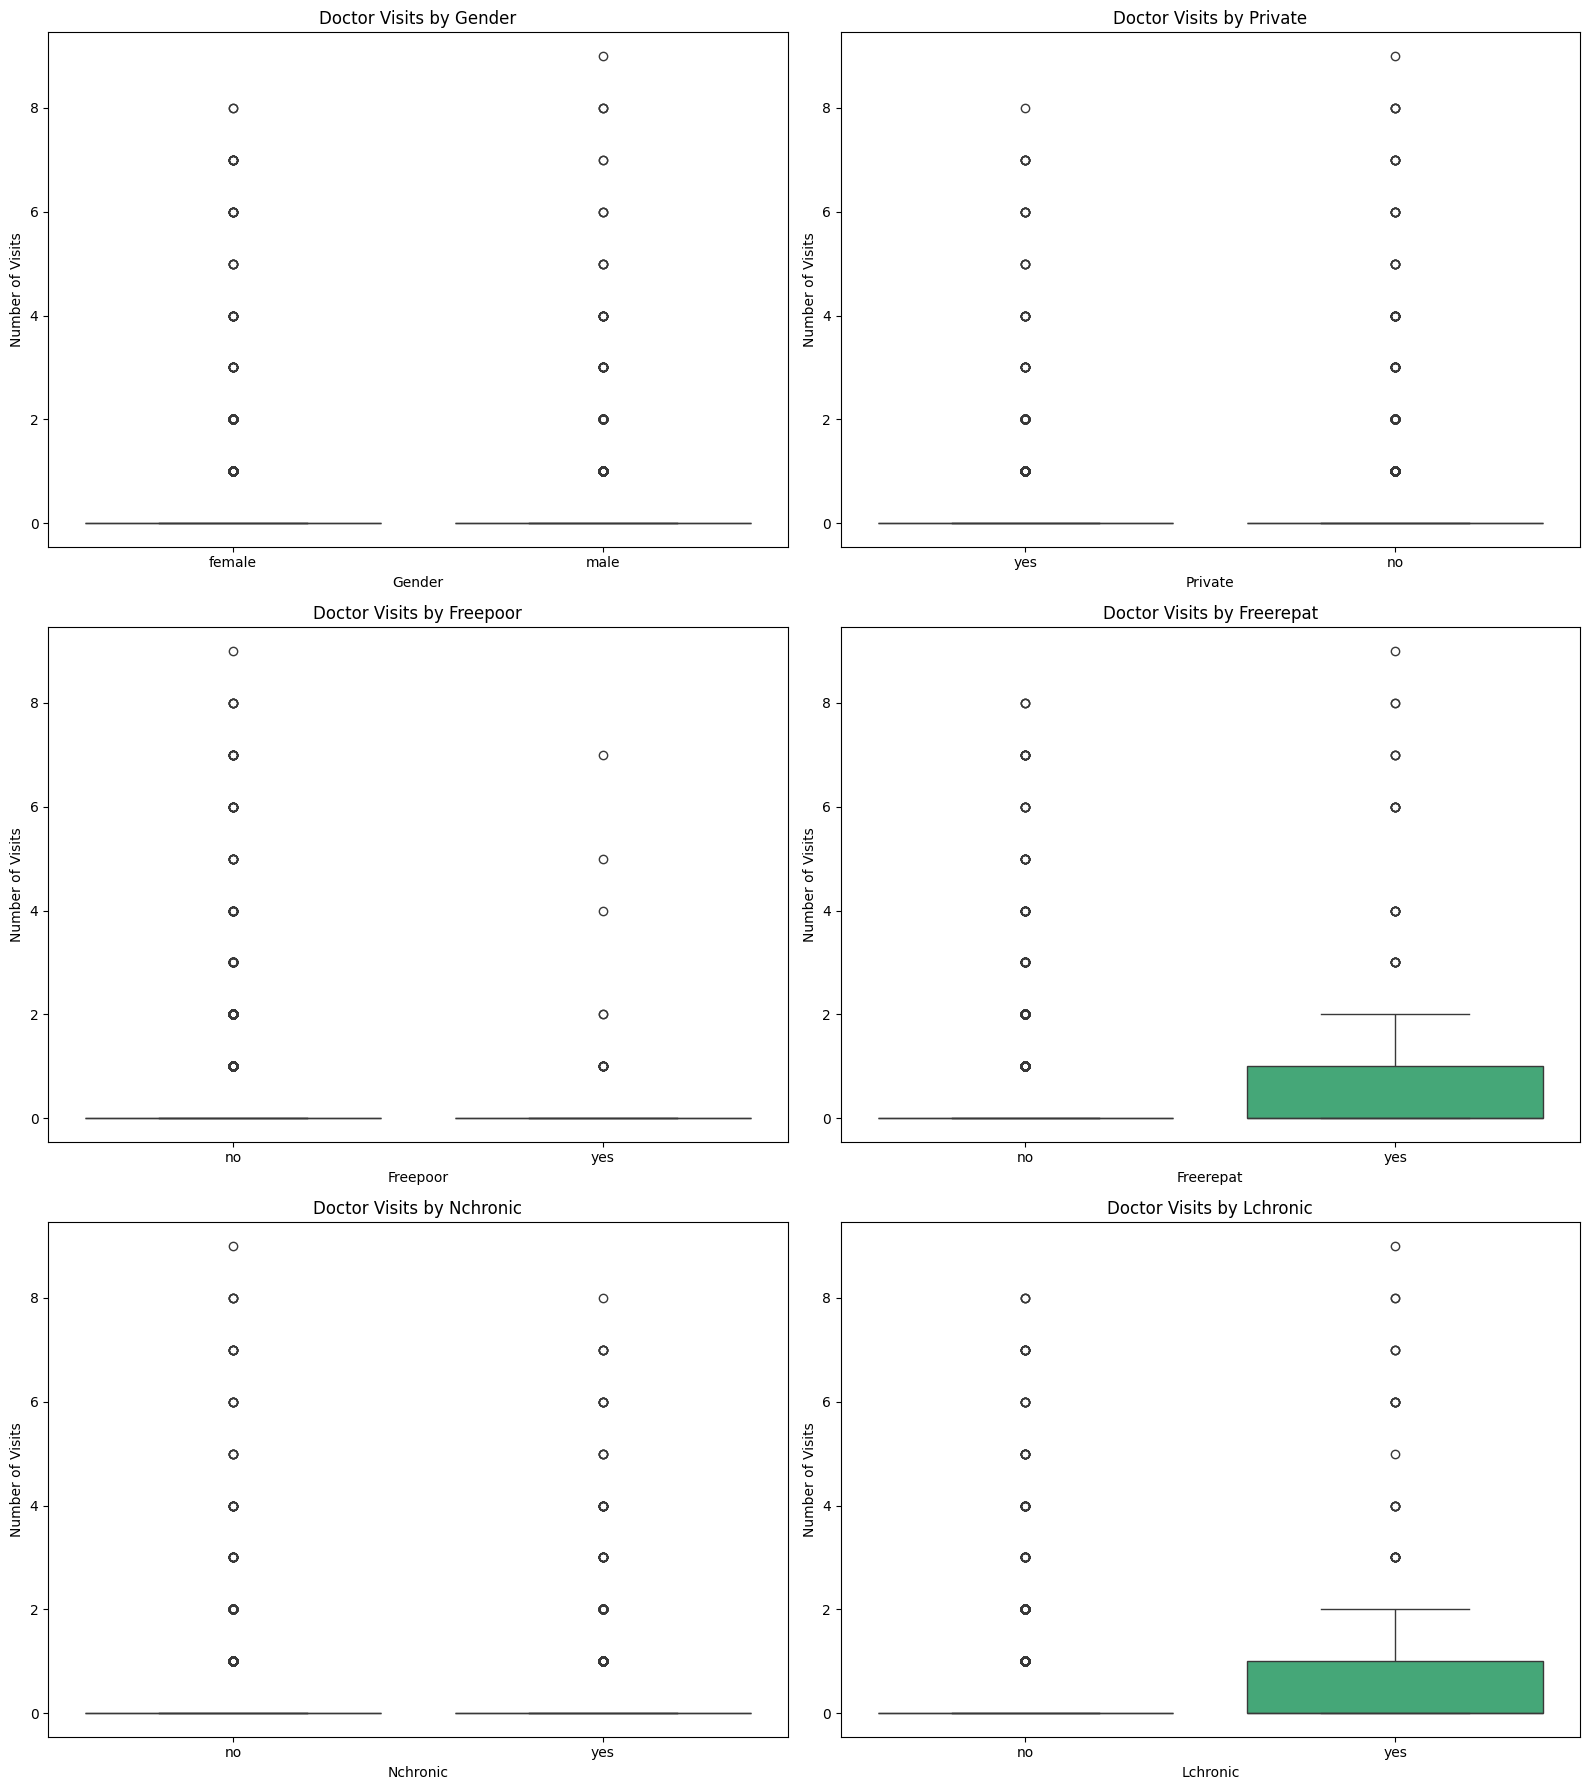

In [144]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

categorical_features = ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']

for i, col in enumerate(categorical_features):
    sns.boxplot(data=df, x=col, y='visits', ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Doctor Visits by {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Number of Visits')

plt.tight_layout()
plt.show()

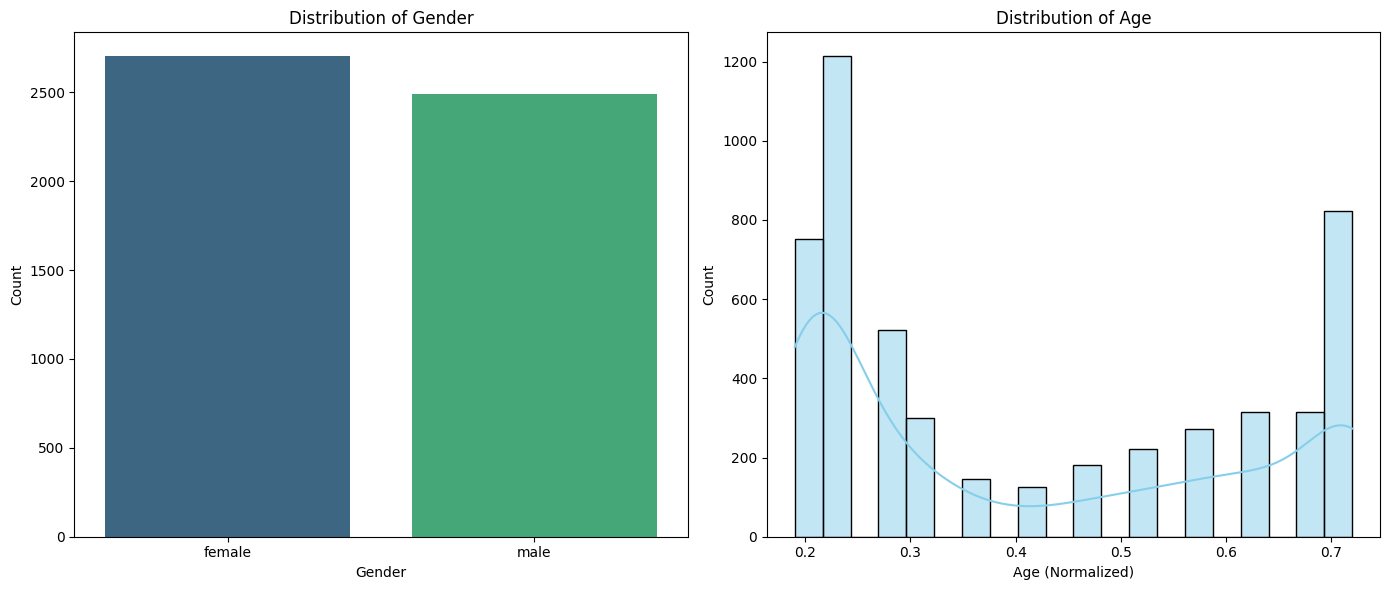

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x='gender', hue='gender', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Distribution of Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

sns.histplot(df['age'], bins=20, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Age')
axes[1].set_xlabel('Age (Normalized)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [146]:
print("\nData types and non-null values for each column:")
df.info()

print("\nMissing values count per column:")
print(df.isnull().sum())


Data types and non-null values for each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB

Missing values count per column:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
pri

## 7. Descriptive Statistics

Descriptive statistics provide a numerical summary of the healthcare dataset.
This section examines the central tendency, variability, range, and distribution
of the major numerical variables.

The analysis focuses particularly on doctor visits, age, income, illness,
reduced activity, and health-related variables.

In [147]:
# Descriptive statistics for numerical variables
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00


In [148]:
# Detailed descriptive statistics
numerical_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health']

descriptive_stats = df_clean[numerical_cols].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).T

descriptive_stats

,count,mean,median,std,min,max
visits,5190.0,0.301734,0.00,0.798134,0.00,9.00
age,5190.0,0.406385,0.32,0.204782,0.19,0.72
income,5190.0,0.583160,0.55,0.368907,0.00,1.50
illness,5190.0,1.431985,1.00,1.384152,0.00,5.00
reduced,5190.0,0.861850,0.00,2.887628,0.00,14.00
health,5190.0,1.217534,0.00,2.124266,0.00,12.00


In [149]:
# Quartiles and range
quartile_stats = pd.DataFrame({
    'Q1': df_clean[numerical_cols].quantile(0.25),
    'Median': df_clean[numerical_cols].quantile(0.50),
    'Q3': df_clean[numerical_cols].quantile(0.75),
    'Range': df_clean[numerical_cols].max() - df_clean[numerical_cols].min()
})

quartile_stats

,Q1,Median,Q3,Range
visits,0.00,0.00,0.00,9.00
age,0.22,0.32,0.62,0.53
income,0.25,0.55,0.90,1.50
illness,0.00,1.00,2.00,5.00
reduced,0.00,0.00,0.00,14.00
health,0.00,0.00,2.00,12.00


In [150]:
# Frequency and percentage of categorical variables

categorical_cols = [
    'gender',
    'private',
    'freepoor',
    'freerepat',
    'nchronic',
    'lchronic'
]

for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    counts = df_clean[col].value_counts()
    percentages = df_clean[col].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(2)
    })

    display(summary)


--- GENDER ---


,Count,Percentage
gender,,
female,2702,52.06
male,2488,47.94



--- PRIVATE ---


,Count,Percentage
private,,
no,2892,55.72
yes,2298,44.28



--- FREEPOOR ---


...

,Count,Percentage
freerepat,,
no,4099,78.98
yes,1091,21.02



--- NCHRONIC ---


,Count,Percentage
nchronic,,
no,3098,59.69
yes,2092,40.31



--- LCHRONIC ---


,Count,Percentage
lchronic,,
no,4585,88.34
yes,605,11.66


### Interpretation

The descriptive statistics provide an overall understanding of the numerical
variables and their distributions. Doctor visits are concentrated at lower
values, while a smaller number of observations show multiple visits.

The categorical summaries help identify the composition of the dataset across
gender, insurance/access-related variables, and chronic-condition indicators.

These statistics provide a foundation for the visual and relationship-based
analyses performed in the following sections.

## 8. Univariate Exploratory Data Analysis

Univariate analysis examines one variable at a time to understand its
distribution, frequency, and overall pattern.

The analysis includes the main numerical variables and important categorical
variables in the healthcare dataset.

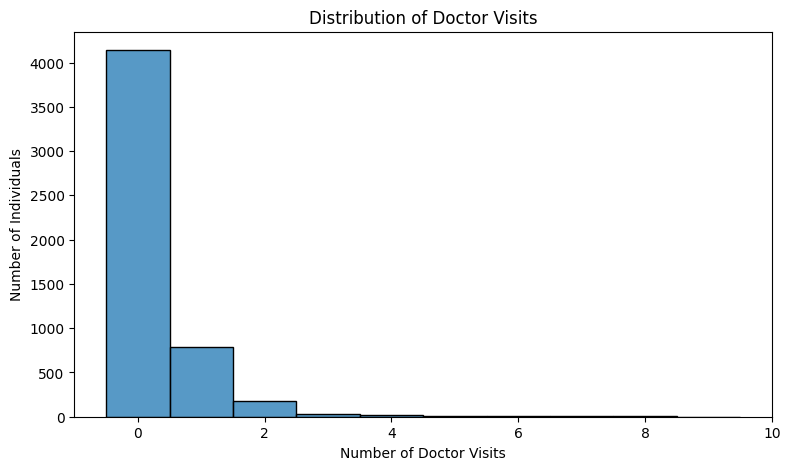

In [151]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x='visits',
    discrete=True,
    kde=False
)

plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Doctor Visits')
plt.ylabel('Number of Individuals')
plt.show()

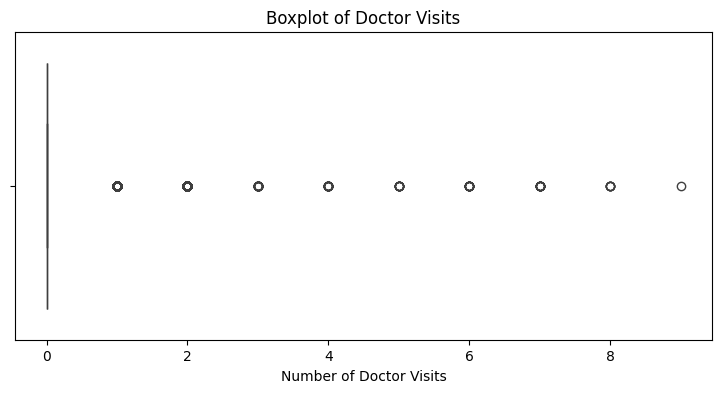

In [152]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df_clean,
    x='visits'
)

plt.title('Boxplot of Doctor Visits')
plt.xlabel('Number of Doctor Visits')
plt.show()

### Interpretation

The distribution of doctor visits is highly concentrated at the lower end.
Most observations correspond to zero or a small number of visits, while only
a relatively small number of observations record higher visit counts.

This indicates that doctor visits are not evenly distributed across the dataset.

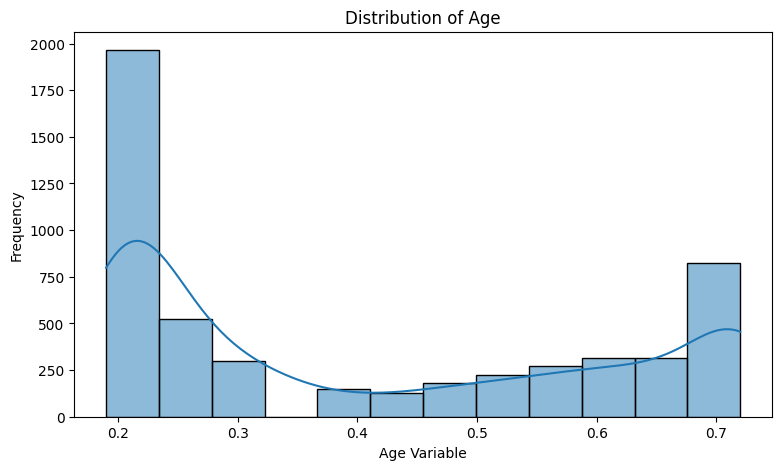

In [153]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x='age',
    bins=12,
    kde=True
)

plt.title('Distribution of Age')
plt.xlabel('Age Variable')
plt.ylabel('Frequency')
plt.show()

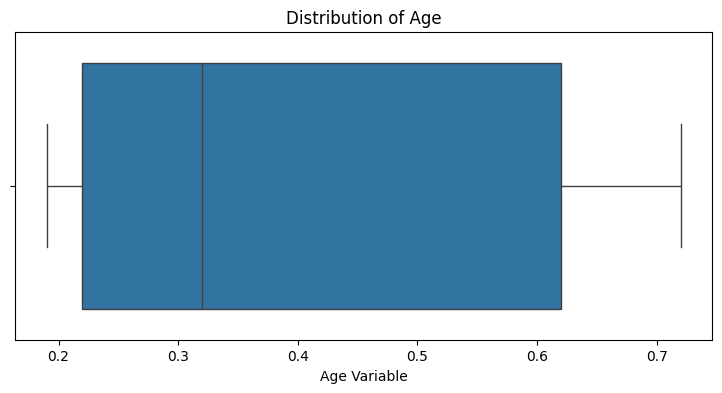

In [154]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df_clean,
    x='age'
)

plt.title('Distribution of Age')
plt.xlabel('Age Variable')
plt.show()

### Interpretation

The age variable is represented using coded numerical values rather than
literal ages in years. The distribution shows how observations are distributed
across the available age categories/encoded values.

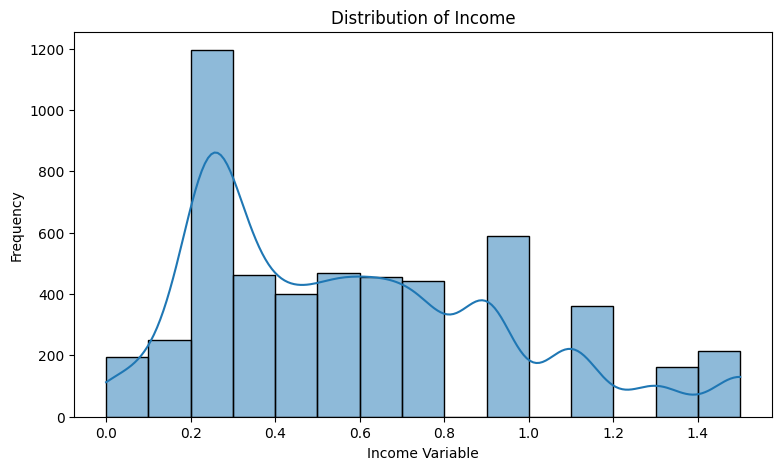

In [155]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x='income',
    bins=15,
    kde=True
)

plt.title('Distribution of Income')
plt.xlabel('Income Variable')
plt.ylabel('Frequency')
plt.show()

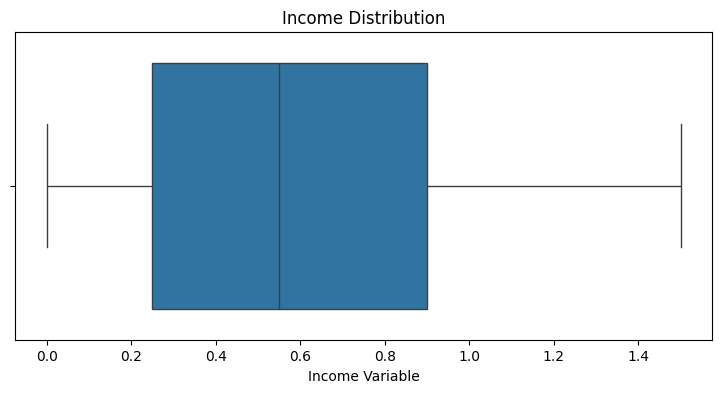

In [156]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df_clean,
    x='income'
)

plt.title('Income Distribution')
plt.xlabel('Income Variable')
plt.show()

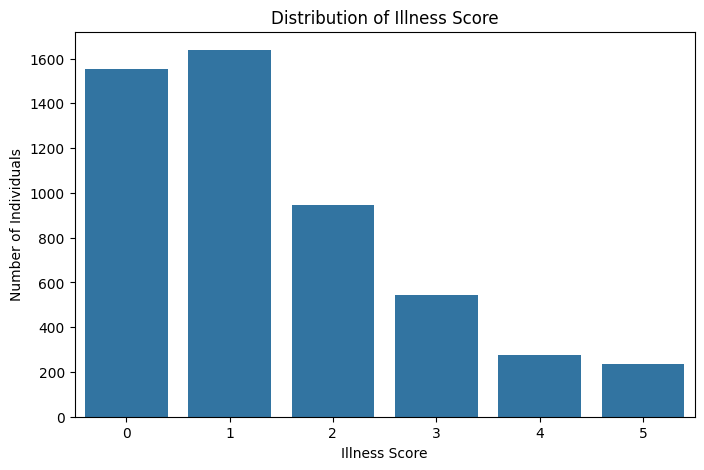

In [157]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x='illness'
)

plt.title('Distribution of Illness Score')
plt.xlabel('Illness Score')
plt.ylabel('Number of Individuals')
plt.show()

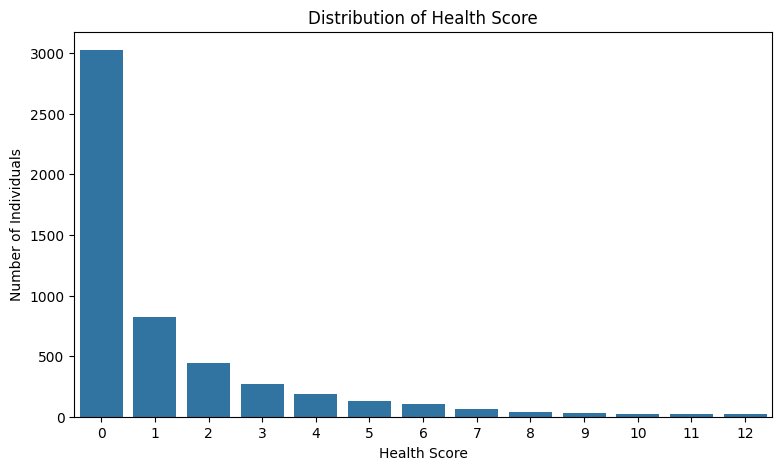

In [158]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x='health'
)

plt.title('Distribution of Health Score')
plt.xlabel('Health Score')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)
plt.show()

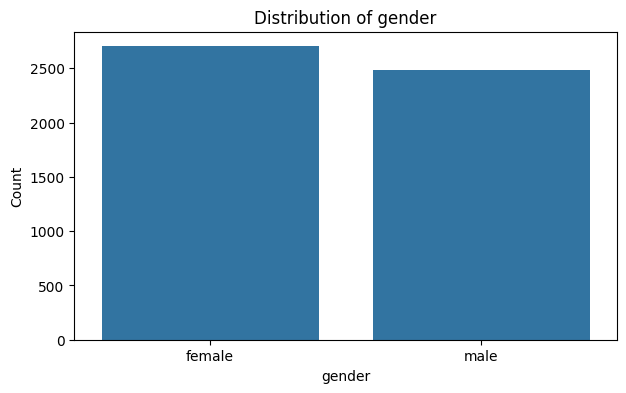

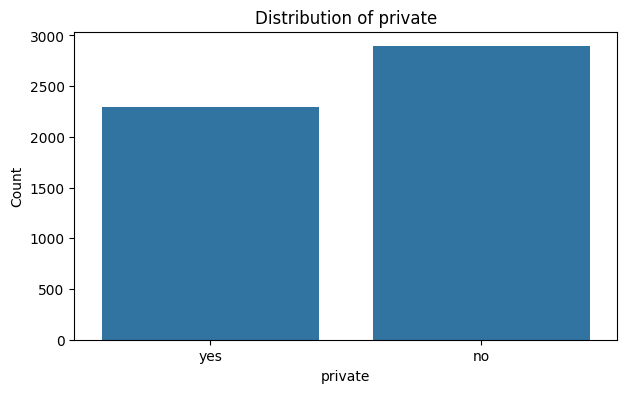

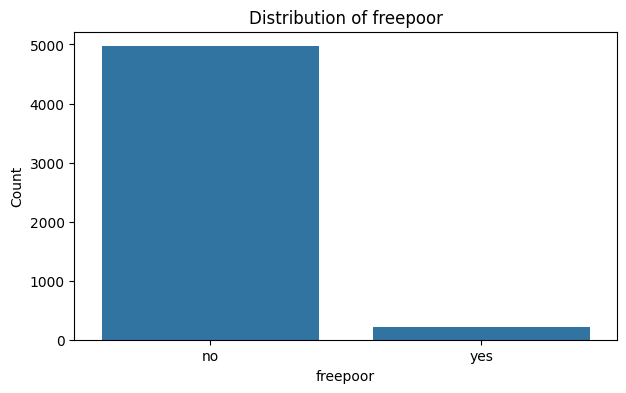

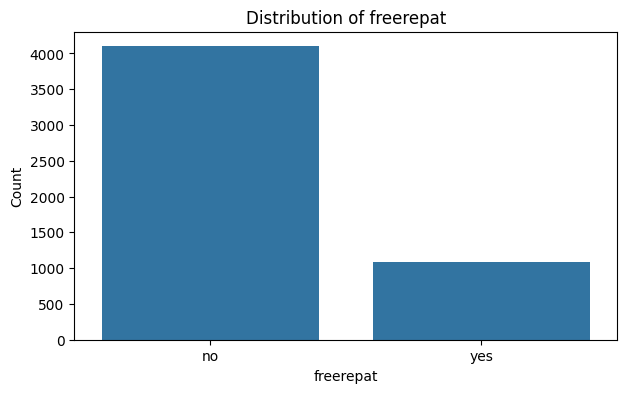

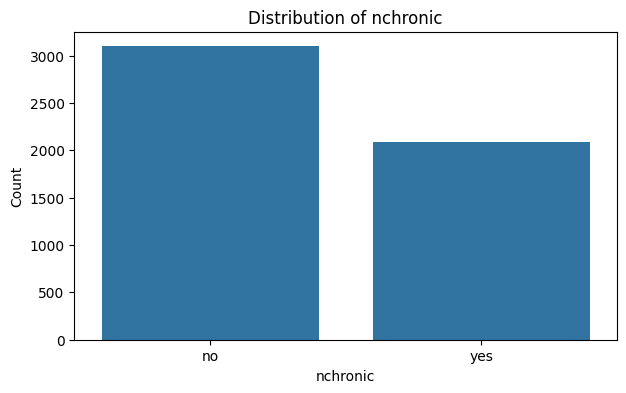

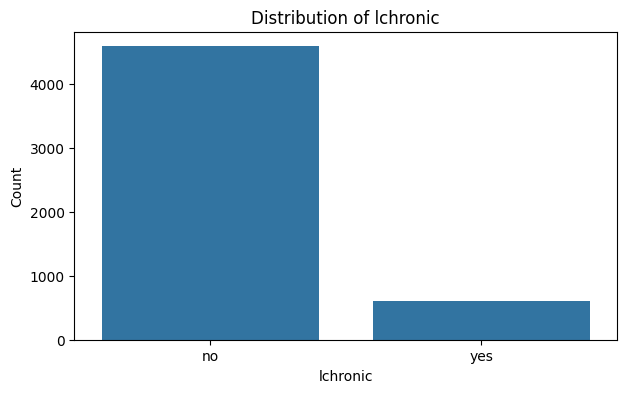

In [159]:
categorical_cols = [
    'gender',
    'private',
    'freepoor',
    'freerepat',
    'nchronic',
    'lchronic'
]

for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df_clean, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

### Univariate Analysis Summary

The univariate analysis shows the basic structure of the dataset. Doctor visits
are concentrated at lower values, while illness, health, reduced activity, age,
and income show different levels of variation. The categorical variables also
show differences in the number of observations across their respective groups.

These distributions provide the basis for investigating relationships between
healthcare utilization and other demographic, socioeconomic, and health-related
variables.

## 9. Bivariate Analysis

Bivariate analysis investigates the relationship between two variables.

The primary focus is on understanding how doctor visits vary according to
demographic, socioeconomic, health, and healthcare-access-related variables.

In [160]:
gender_visits = df_clean.groupby('gender')['visits'].agg(
    ['count', 'mean', 'median']
).reset_index()

gender_visits

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


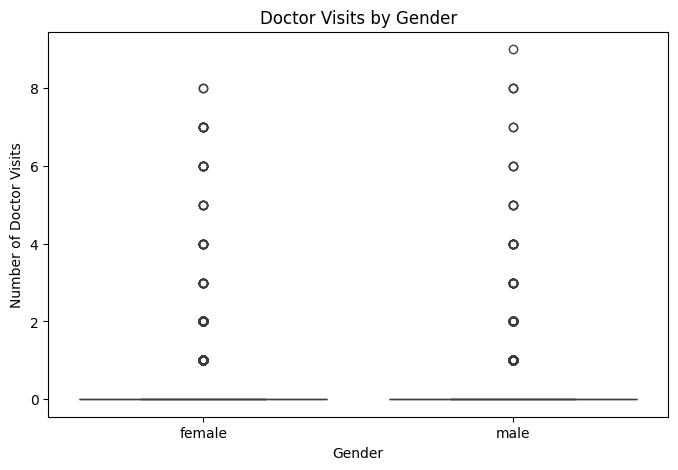

In [161]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='gender',
    y='visits'
)

plt.title('Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Doctor Visits')
plt.show()

### Interpretation

The average recorded number of doctor visits differs between the two gender
groups in this dataset. Female observations have a higher mean number of visits
than male observations.

This represents an association observed in the dataset and should not be
interpreted as evidence that gender causes differences in doctor visits.

In [162]:
illness_visits = df_clean.groupby('illness')['visits'].agg(
    ['count', 'mean', 'median']
).reset_index()

illness_visits

,illness,count,mean,median
0,0,1554,0.078507,0.0
1,1,1638,0.295482,0.0
2,2,946,0.403805,0.0
3,3,542,0.420664,0.0
4,4,274,0.576642,0.0
5,5,236,0.813559,0.0


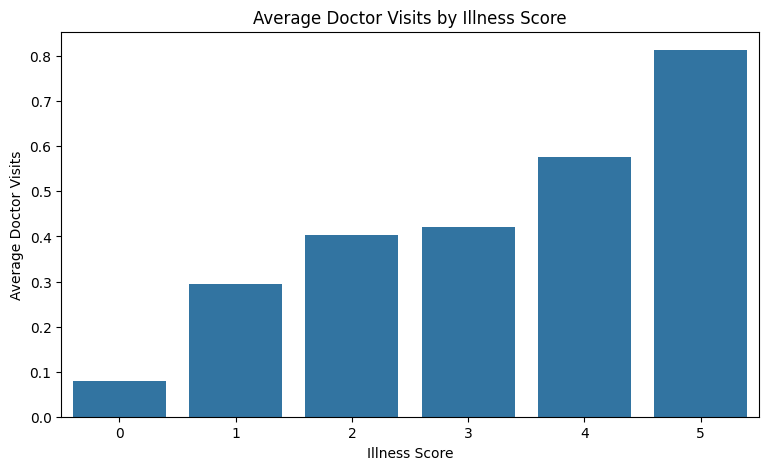

In [163]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=illness_visits,
    x='illness',
    y='mean'
)

plt.title('Average Doctor Visits by Illness Score')
plt.xlabel('Illness Score')
plt.ylabel('Average Doctor Visits')
plt.show()

### Interpretation

Average doctor visits generally increase as the illness score increases.
Individuals with higher illness scores show greater recorded healthcare
utilization in this dataset.

The relationship is observational, so the result indicates association rather
than proving causation.

In [164]:
health_visits = df_clean.groupby('health')['visits'].agg(
    ['count', 'mean', 'median']
).reset_index()

health_visits

,health,count,mean,median
0,0,3026,0.199273,0.0
1,1,823,0.335358,0.0
2,2,446,0.381166,0.0
3,3,273,0.417582,0.0
4,4,187,0.534759,0.0
5,5,132,0.530303,0.0
6,6,104,0.625000,0.0
7,7,61,0.918033,0.0
8,8,42,0.476190,0.0
9,9,32,0.656250,0.0


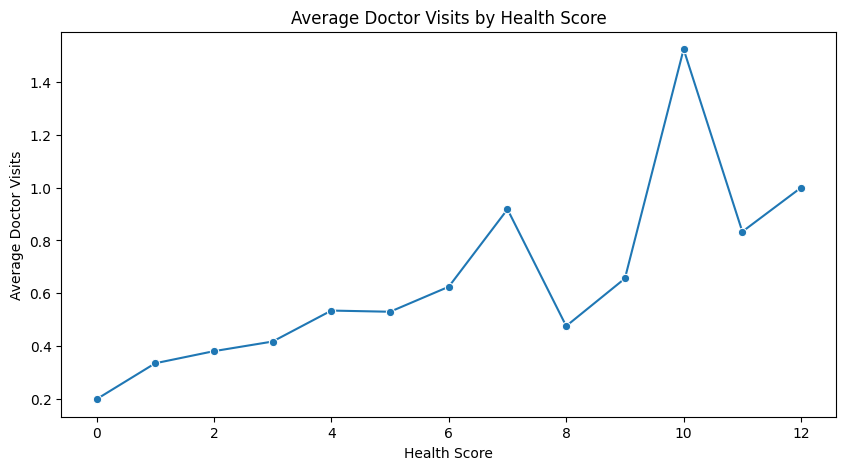

In [165]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=health_visits,
    x='health',
    y='mean',
    marker='o'
)

plt.title('Average Doctor Visits by Health Score')
plt.xlabel('Health Score')
plt.ylabel('Average Doctor Visits')
plt.show()

In [166]:
reduced_visits = df_clean.groupby('reduced')['visits'].agg(
    ['count', 'mean', 'median']
).reset_index()

reduced_visits

,reduced,count,mean,median
0,0,4454,0.183880,0.0
1,1,177,0.355932,0.0
2,2,108,0.574074,0.0
3,3,74,1.094595,1.0
4,4,45,0.800000,1.0
5,5,40,1.275000,1.0
6,6,17,1.176471,1.0
7,7,38,1.184211,1.0
8,8,17,1.176471,1.0
9,9,7,1.714286,1.0


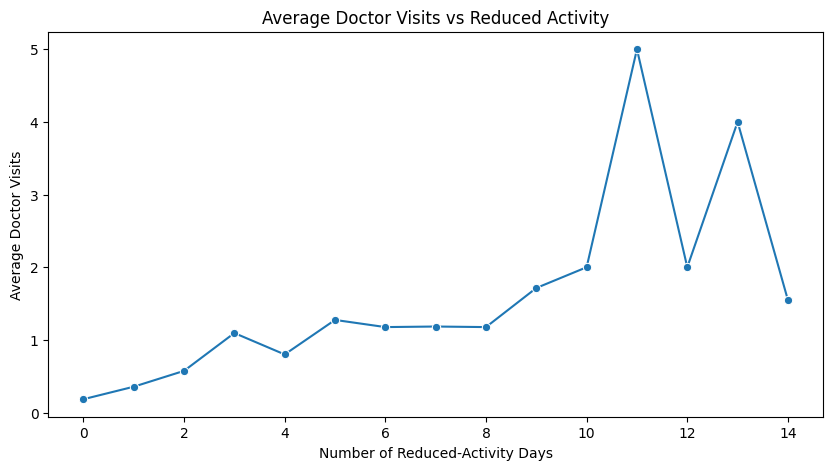

In [167]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=reduced_visits,
    x='reduced',
    y='mean',
    marker='o'
)

plt.title('Average Doctor Visits vs Reduced Activity')
plt.xlabel('Number of Reduced-Activity Days')
plt.ylabel('Average Doctor Visits')
plt.show()

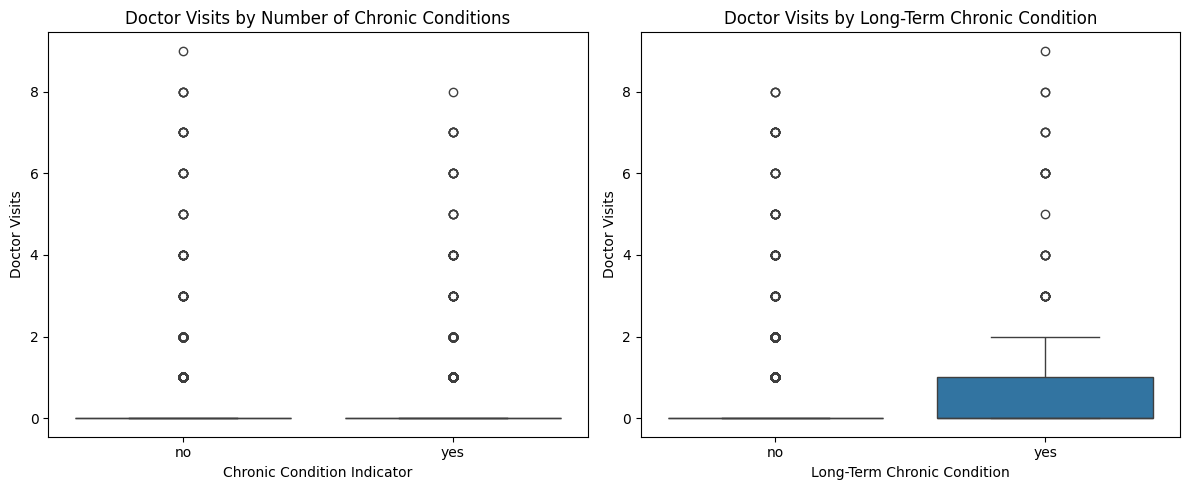

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df_clean,
    x='nchronic',
    y='visits',
    ax=axes[0]
)

axes[0].set_title('Doctor Visits by Number of Chronic Conditions')
axes[0].set_xlabel('Chronic Condition Indicator')
axes[0].set_ylabel('Doctor Visits')

sns.boxplot(
    data=df_clean,
    x='lchronic',
    y='visits',
    ax=axes[1]
)

axes[1].set_title('Doctor Visits by Long-Term Chronic Condition')
axes[1].set_xlabel('Long-Term Chronic Condition')
axes[1].set_ylabel('Doctor Visits')

plt.tight_layout()
plt.show()

In [169]:
for col in ['nchronic', 'lchronic']:
    print(f"\n{col}")
    display(
        df_clean.groupby(col)['visits']
        .agg(['count', 'mean', 'median'])
        .reset_index()
    )


nchronic


,nchronic,count,mean,median
0,no,3098,0.272111,0.0
1,yes,2092,0.345602,0.0



lchronic


,lchronic,count,mean,median
0,no,4585,0.261941,0.0
1,yes,605,0.603306,0.0


## 10. Feature Engineering for Analytical Groups

The original age and income variables are numerically encoded. To make group-level
comparisons easier to communicate, analytical categories will be created without
modifying the original variables.

The original variables will be retained for numerical analysis.

In [170]:
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 0.25, 0.40, 0.55, 0.73],
    labels=['Lower', 'Lower-Middle', 'Upper-Middle', 'Higher'],
    include_lowest=True
)

df_clean['age_group'].value_counts().sort_index()

,count
age_group,
Lower,1965
Lower-Middle,970
Upper-Middle,529
Higher,1726


In [171]:
df_clean['income_group'] = pd.cut(
    df_clean['income'],
    bins=[-0.01, 0.40, 0.80, 1.20, 1.50],
    labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'],
    include_lowest=True
)

df_clean['income_group'].value_counts().sort_index()

,count
income_group,
Low,2100
Lower-Middle,1763
Upper-Middle,950
High,377


In [172]:
age_group_visits = (
    df_clean.groupby('age_group', observed=False)['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

age_group_visits

,age_group,count,mean,median
0,Lower,1965,0.205598,0.0
1,Lower-Middle,970,0.251546,0.0
2,Upper-Middle,529,0.342155,0.0
3,Higher,1726,0.426999,0.0


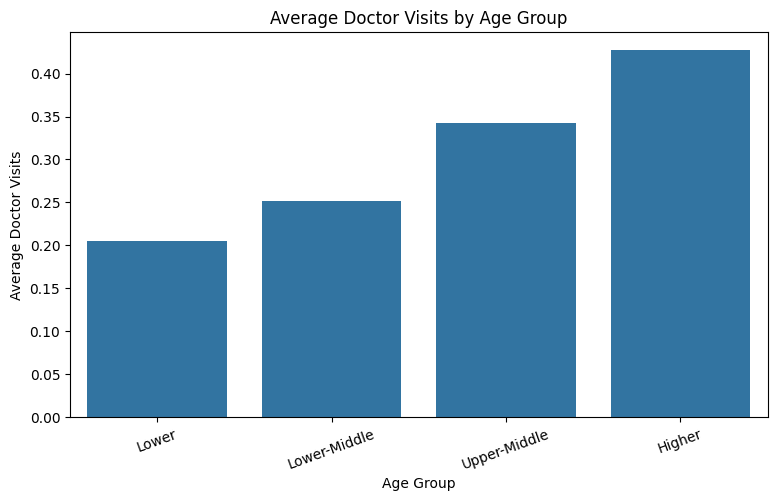

In [173]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_group_visits,
    x='age_group',
    y='mean'
)

plt.title('Average Doctor Visits by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Doctor Visits')
plt.xticks(rotation=20)
plt.show()

In [174]:
income_group_visits = (
    df_clean.groupby('income_group', observed=False)['visits']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)

income_group_visits

,income_group,count,mean,median
0,Low,2100,0.389524,0.0
1,Lower-Middle,1763,0.260919,0.0
2,Upper-Middle,950,0.195789,0.0
3,High,377,0.270557,0.0


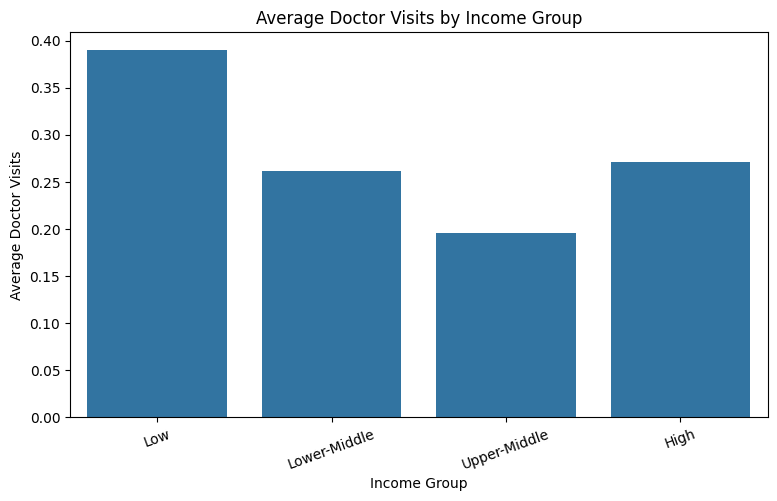

In [175]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=income_group_visits,
    x='income_group',
    y='mean'
)

plt.title('Average Doctor Visits by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Average Doctor Visits')
plt.xticks(rotation=20)
plt.show()

## 11. Multivariate Analysis

Multivariate analysis examines multiple variables simultaneously to identify
more meaningful patterns in healthcare utilization.

This section combines demographic, socioeconomic, and health-related variables
to provide a deeper understanding of doctor visit patterns.

In [176]:
age_gender = (
    df_clean.groupby(['age_group', 'gender'], observed=False)['visits']
    .mean()
    .reset_index()
)

age_gender

,age_group,gender,visits
0,Lower,female,0.249102
1,Lower,male,0.173451
2,Lower-Middle,female,0.396011
3,Lower-Middle,male,0.169628
4,Upper-Middle,female,0.379182
5,Upper-Middle,male,0.303846
6,Higher,female,0.424218
7,Higher,male,0.434238


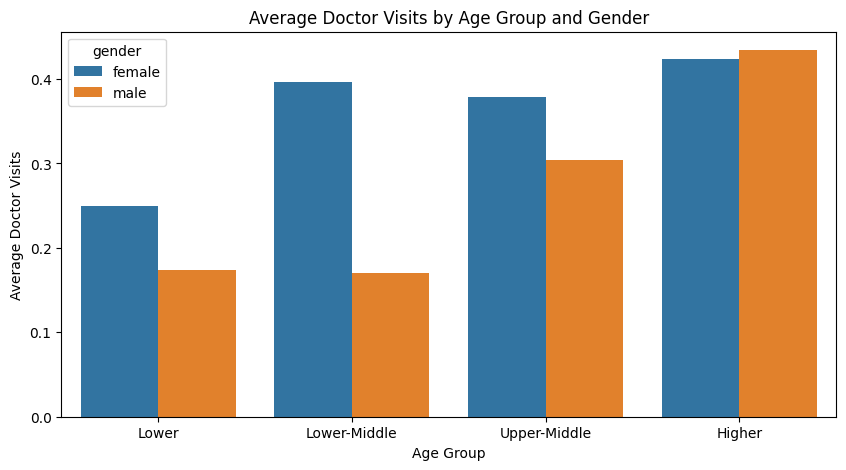

In [177]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_gender,
    x='age_group',
    y='visits',
    hue='gender'
)

plt.title('Average Doctor Visits by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Average Doctor Visits')
plt.show()

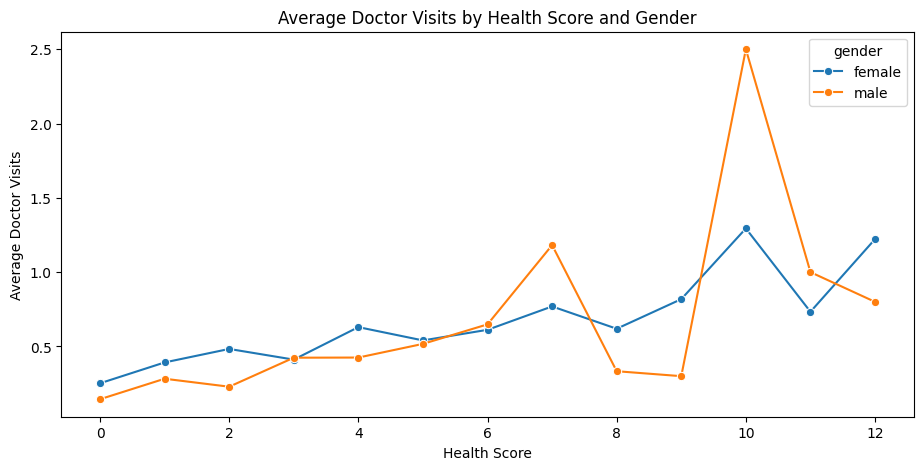

In [178]:
health_gender = (
    df_clean.groupby(['health', 'gender'])['visits']
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=health_gender,
    x='health',
    y='visits',
    hue='gender',
    marker='o'
)

plt.title('Average Doctor Visits by Health Score and Gender')
plt.xlabel('Health Score')
plt.ylabel('Average Doctor Visits')
plt.show()

In [179]:
chronic_gender = pd.pivot_table(
    df_clean,
    values='visits',
    index='nchronic',
    columns='gender',
    aggfunc='mean'
)

chronic_gender

gender,female,male
nchronic,,
no,0.345095,0.210589
yes,0.380545,0.289963


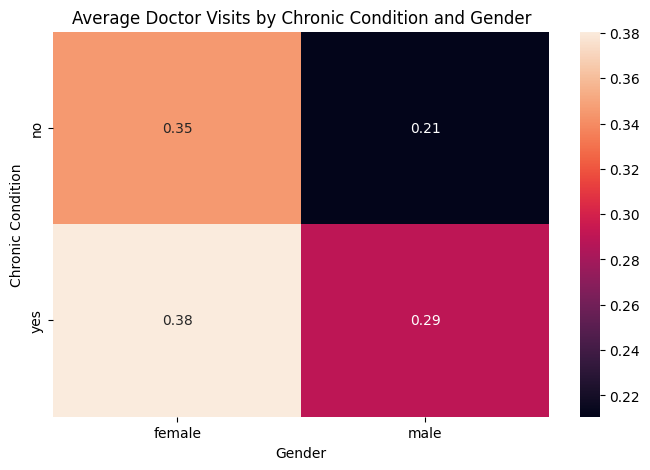

In [180]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    chronic_gender,
    annot=True,
    fmt='.2f'
)

plt.title('Average Doctor Visits by Chronic Condition and Gender')
plt.xlabel('Gender')
plt.ylabel('Chronic Condition')
plt.show()

## 12. Correlation Analysis

Correlation analysis is used to measure the strength and direction of linear
relationships between numerical variables.

This section focuses particularly on the relationship between doctor visits
and the main numerical health and socioeconomic variables.

In [181]:
correlation_cols = [
    'visits',
    'age',
    'income',
    'illness',
    'reduced',
    'health'
]

correlation_matrix = df_clean[correlation_cols].corr()

correlation_matrix

,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


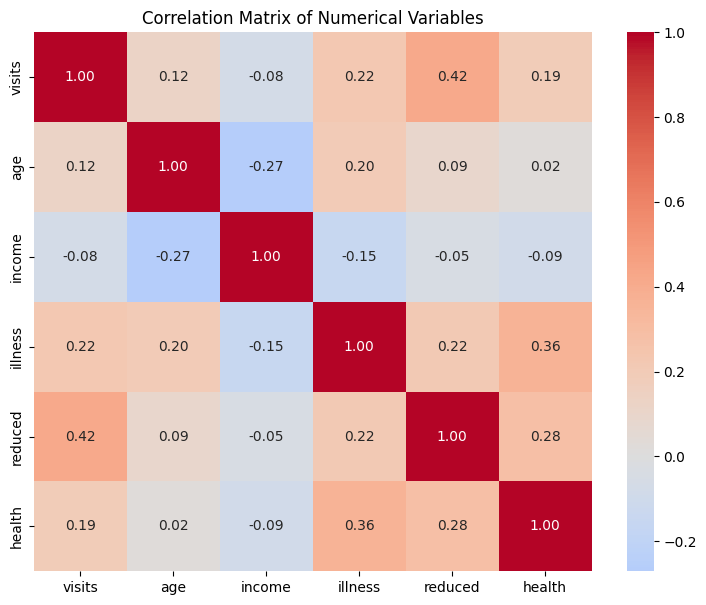

In [182]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Interpretation

Among the numerical variables examined, reduced activity has the strongest
positive correlation with doctor visits. Illness and health also show positive
relationships with visits, while age has a weaker positive relationship.

Income has a weak negative correlation with doctor visits in this dataset.

Correlation measures association and does not establish causation.

## 13. Outlier Analysis

Outlier analysis identifies unusually high or low observations in numerical
variables. In healthcare datasets, unusual observations may represent legitimate
individual differences rather than data-entry errors.

Therefore, potential outliers will be identified but not automatically removed.

In [183]:
outlier_cols = ['visits', 'age', 'income', 'illness', 'reduced', 'health']

outlier_results = []

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ]

    outlier_results.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df_clean) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,visits,0.00,0.00,0.00,0.000,0.000,1049,20.21
1,age,0.22,0.62,0.40,-0.380,1.220,0,0.00
2,income,0.25,0.90,0.65,-0.725,1.875,0,0.00
3,illness,0.00,2.00,2.00,-3.000,5.000,0,0.00
4,reduced,0.00,0.00,0.00,0.000,0.000,736,14.18
5,health,0.00,2.00,2.00,-3.000,5.000,303,5.84


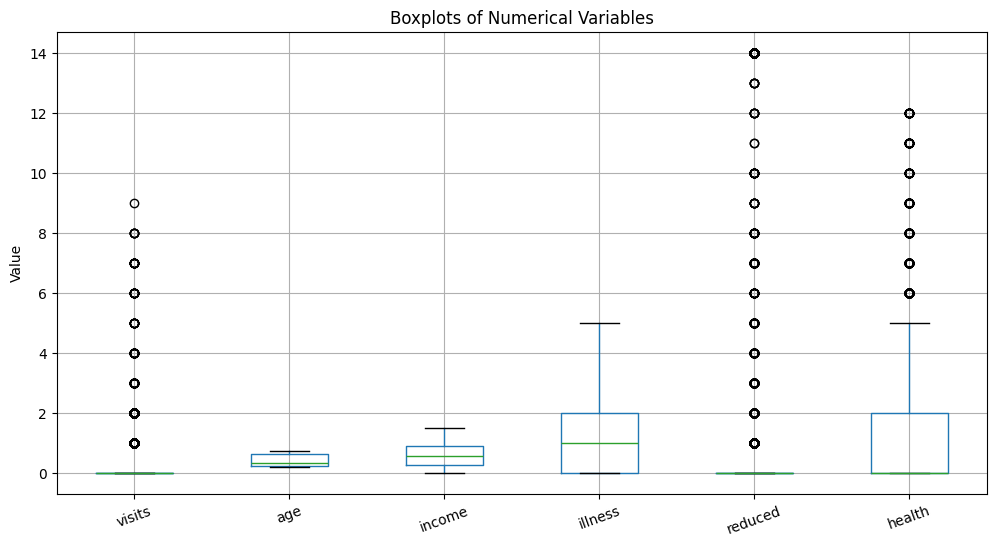

In [184]:
plt.figure(figsize=(12, 6))

df_clean[outlier_cols].boxplot()

plt.title('Boxplots of Numerical Variables')
plt.ylabel('Value')
plt.xticks(rotation=20)
plt.show()

## 14. Statistical Hypothesis Testing

Statistical hypothesis testing is used to determine whether observed differences
between groups are likely to reflect more than random variation.

Because doctor visits are highly concentrated at zero and are not normally
distributed, non-parametric tests are used where appropriate.

In [185]:
from scipy.stats import mannwhitneyu

female_visits = df_clean.loc[
    df_clean['gender'] == 'female',
    'visits'
]

male_visits = df_clean.loc[
    df_clean['gender'] == 'male',
    'visits'
]

stat, p_value = mannwhitneyu(
    female_visits,
    male_visits,
    alternative='two-sided'
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U statistic: 3655194.5
p-value: 6.338282349980026e-15


In [186]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("There is statistically significant evidence of a difference in doctor visits between the two gender groups.")
else:
    print("Decision: Do not reject the null hypothesis.")
    print("There is not sufficient statistical evidence of a difference in doctor visits between the two gender groups.")

Decision: Reject the null hypothesis.
There is statistically significant evidence of a difference in doctor visits between the two gender groups.


In [187]:
yes_visits = df_clean.loc[
    df_clean['lchronic'] == 'yes',
    'visits'
]

no_visits = df_clean.loc[
    df_clean['lchronic'] == 'no',
    'visits'
]

stat, p_value = mannwhitneyu(
    yes_visits,
    no_visits,
    alternative='two-sided'
)

print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U statistic: 1629677.0
p-value: 1.1970789999983834e-23


## 15. Key Findings

The major findings from the healthcare analytics project are summarized below.
These findings are based on the descriptive statistics, exploratory analysis,
relationship analysis, correlation analysis, and hypothesis testing conducted
in this notebook.

### Major Findings

1. Doctor visits are highly concentrated at zero or low values, with only a
   small proportion of observations showing multiple visits.

2. The average number of doctor visits differs between the gender groups, with
   the female group showing a higher mean in this dataset.

3. Average doctor visits generally increase as the illness score increases.

4. Reduced activity shows the strongest positive correlation with doctor visits
   among the main numerical variables analyzed.

5. Health and illness measures show positive relationships with doctor visits.

6. The relationship between income and doctor visits is weak compared with the
   relationships involving health-related variables.

7. The chronic-condition indicators are associated with differences in the
   average number of doctor visits.

8. The distributions of doctor visits and several health variables are
   skewed, making non-parametric statistical methods useful for group comparisons.

9. Potential outliers were identified in several numerical variables. These were
   retained because unusual healthcare-utilization values may represent genuine
   observations rather than data errors.

10. The analysis demonstrates associations within the dataset but does not
    establish causal relationships.

## 16. Healthcare Analytics Insights

The analysis provides several insights into patterns of healthcare utilization.

### 1. Health-related factors
Higher illness and reduced-activity levels are associated with greater numbers
of doctor visits, suggesting that health status is closely related to healthcare
utilization in the dataset.

### 2. Chronic conditions
Individuals identified with chronic conditions show different patterns of
doctor visits compared with those without the corresponding condition indicators.

### 3. Demographic differences
Doctor-visit patterns differ across gender and age-related groups, indicating
that healthcare utilization is not uniform across the population.

### 4. Socioeconomic factors
Income shows a comparatively weak relationship with doctor visits in the
available data, although this does not mean socioeconomic factors are
unimportant in healthcare access or utilization.

### 5. Resource planning
Healthcare organizations could use similar analytics to identify groups with
higher levels of healthcare utilization and better understand service-demand
patterns.

## 17. Limitations

1. The dataset is observational, so the analysis identifies associations rather
   than proving cause-and-effect relationships.

2. Several variables are represented using coded or scaled values, so their
   interpretation depends on the original dataset documentation.

3. Important factors that may influence doctor visits may not be present in the
   dataset.

4. Grouping numerical variables into categories improves interpretability but
   can result in some loss of information.

5. Statistical significance does not necessarily imply practical or clinical
   importance.

6. The results should not automatically be generalized to every healthcare
   population because the characteristics of the dataset and its source may
   limit generalizability.

7. Potential outliers may represent legitimate healthcare utilization patterns
   rather than errors and therefore were not automatically removed.

## 18. Conclusion

This project analyzed a healthcare dataset containing information related to
doctor visits, demographics, socioeconomic characteristics, illness, health,
reduced activity, healthcare access, and chronic conditions.

The analysis used data cleaning, descriptive statistics, exploratory data
analysis, bivariate and multivariate analysis, correlation analysis, outlier
analysis, and statistical hypothesis testing.

The results indicate that doctor visits are associated with several health and
activity-related variables, particularly illness and reduced activity.
Differences are also observed across demographic and chronic-condition groups.

Overall, the project demonstrates how data analytics can be used to identify
patterns in healthcare utilization and transform raw healthcare data into
interpretable insights.

However, the findings represent associations within the dataset and should not
be interpreted as evidence of causation.

## 19. Future Scope

The project could be extended in several ways:

- Incorporating additional demographic and healthcare variables.
- Adding geographic and time-based information.
- Building an interactive dashboard using Power BI, Tableau, or Plotly.
- Performing patient segmentation using clustering techniques.
- Developing predictive models for healthcare utilization.
- Comparing healthcare utilization across different populations.
- Incorporating more recent healthcare data.
- Applying advanced statistical and machine-learning methods.